# 삼박자 - 최종 프로젝트

In [1]:
# 20250109 샘플 데이터셋 전처리 밑작업
# 20250113 전처리 코드 정리 & EDA 시각화 추가
# 20250115 skinsort 브랜드 관련 데이터 추가
# 20250116 아마존 최종 데이터로 전처리 등 코드 수정

# PART 1: Data Preprocessing

### Import library & Load data

In [1]:
from src.util.repo_paths import AMAZON
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import datetime
import re
import string
import nltk
import os
import warnings

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import intercluster_distance
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


warnings.filterwarnings('ignore')

DATA_PATH = "/Users/jun/GitStudy/Data_4/Data/project5/M/"

def load_data(data_path, file):
    path = os.path.join(data_path, file)
    return pd.read_csv(path)

item_df = load_data(DATA_PATH,'items.csv' )
review_df = load_data(DATA_PATH,'reviews.csv')
skinsort_df = load_data(DATA_PATH,'skinsort_0115.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jun/GitStudy/Data_4/Data/project5/M/items.csv'

In [3]:
item_df.head()

,ASIN,title,order,category,brand,price,global_rating_count,description,Special_Feature,total_star_mean,detail_dict,best_sellers_rank_Feature
0,B000BRKSAO,Alchimie Forever Rejuvenating Eye Balm | Hydra...,109,Personal Care Products,Alchimie Forever,47.00,43,2 in 1 EYE BALM: This hydrating and nourishing...,"Lightweight, Anti Aging",4.1,"{""ASIN"": ""B000BRKSAO"", ""Manufacturer"": ""Alchim...","#152,144 in Beauty & Personal Care (See Top 10..."
1,B000PI33IS,"K I.C.O.N. Mane Control, Hairstyling Gel. Give...",77,Hair Care Products,No brand,31.99,14,CONTAIN YOUR MANE: Add shape and definition to...,No special feature,5.0,"{""UPC"": ""794437346182 893627000474 79443734237...","#193,764 in Beauty & Personal Care (See Top 10..."
2,B00110OK54,ATOPALM Intensive Moisturizing Cream for Dry &...,29,Personal Care Products,ATOPALM,27.72,774,Important Information: The date on the packagi...,Hypoallergenic,4.5,"{""ASIN"": ""B00110OK54"", ""Department"": ""Skin Car...","#36,781 in Beauty & Personal Care (See Top 100..."
3,B003YJ1H24,Rinju Beauté Réelle Body & Hand Cream - Non-Gr...,114,Skin Care Products,Rinju,13.58,233,Ultimate Skin Care Solution: Our body cream fo...,Aromatherapy,4.7,"{""UPC"": ""759894208244 697896010185"", ""ASIN"": ""...","#183,296 in Beauty & Personal Care (See Top 10..."
4,B003YUW0ZG,ATOPALM Moisturizing Hand Treatment hydrate so...,19,"Foot, Hand & Nail Care Products",ATOPALM,9.60,33,[No.1 K-Beauty Brand] No. 1 Brand Power Index ...,Lightweight,4.6,"{""UPC"": ""857811002057"", ""ASIN"": ""B003YUW0ZG"", ...","#121,462 in Beauty & Personal Care (See Top 10..."


In [8]:
# 전체적인 데이터 정보 EDA
def eda_overveiw(df):

    import pandas as pd
    
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    
    print(f"\n=================== DATA OVERVIEW ===================")
    
    # 데이터 상단부 확인
    print("\n----------------- Head -----------------")
    print(df.head())
    print("=" * 60)

    # 데이터 정보 및 크기 확인
    print("\n--------------- Information ---------------")
    print(df.info())
    print(f"\nSize: {df.size}")
    print(f"Shape: {df.shape}")
    print("=" * 60)

    # 결측치 확인
    print("\n--------------- Missing Values ---------------")
    print(df.isnull().sum())
    print("=" * 60)

    # 중복값 확인
    print("\n--------------- Duplicate Values ---------------")
    print(df.duplicated().value_counts())
    print("=" * 60)

    # 데이터 기술통계량 확인 (int, float type)
    print("\n------------ Descriptive Statistics (Numeric) ------------")
    print(df.describe())
    print("=" * 60)

    # 데이터 기술통계량 확인 (object type)
    print("\n------------ Descriptive Statistics (Categorical) ------------")
    
    try:
        print(df.describe(include=[object]))
        
    except:  
        object_cols = df.select_dtypes(include=['object']).columns
        error_cols = []
        
        for col in object_cols:
            if df[col].apply(lambda x: isinstance(x, (list, dict))).any():
                error_cols.append(col)
        print(f"{error_cols} Excluded")
        print(df.loc[:, ~df.columns.isin(error_cols)].describe(include=[object]))
    
    print("=" * 60)
    
eda_overveiw(item_df)


=================== DATA OVERVIEW ===================

----------------- Head -----------------
         ASIN                                              title  order  \
0  B000BRKSAO  Alchimie Forever Rejuvenating Eye Balm | Hydra...    109   
1  B000PI33IS  K I.C.O.N. Mane Control, Hairstyling Gel. Give...     77   
2  B00110OK54  ATOPALM Intensive Moisturizing Cream for Dry &...     29   
3  B003YJ1H24  Rinju Beauté Réelle Body & Hand Cream - Non-Gr...    114   
4  B003YUW0ZG  ATOPALM Moisturizing Hand Treatment hydrate so...     19   

                          category             brand  price  \
0           Personal Care Products  Alchimie Forever  47.00   
1               Hair Care Products          No brand  31.99   
2           Personal Care Products           ATOPALM  27.72   
3               Skin Care Products             Rinju  13.58   
4  Foot, Hand & Nail Care Products           ATOPALM   9.60   

  global_rating_count                                        description 

### Data Cleaning

> 결측치 처리

#### copy original data

In [9]:
# 분석 & 전처리용으로 원본 데이터 복사
item_copy = item_df.copy()
review_copy = review_df.copy()
skinsort_copy = skinsort_df.copy()

# 결측값 정리
# item 데이터에 결측값 np.nan 으로 변경
item_copy['brand'].replace('No brand', np.nan, inplace=True)
item_copy['best_sellers_rank_Feature'].replace('No result', np.nan, inplace=True)
item_copy['global_rating_count'].replace('No rating', np.nan, inplace=True)
item_copy['Special_Feature'].replace('No special feature', np.nan, inplace=True)

# review 데이터에 결측값 np.nan 으로 변경
review_copy['date'].replace('No date', np.nan, inplace=True)
review_copy['review_rating'].replace('No review', np.nan, inplace=True)

ASIN                           0
title                          0
order                          0
category                       0
brand                        381
price                         24
global_rating_count          448
description                   59
Special_Feature              860
total_star_mean              448
detail_dict                    0
best_sellers_rank_Feature    283
dtype: int64


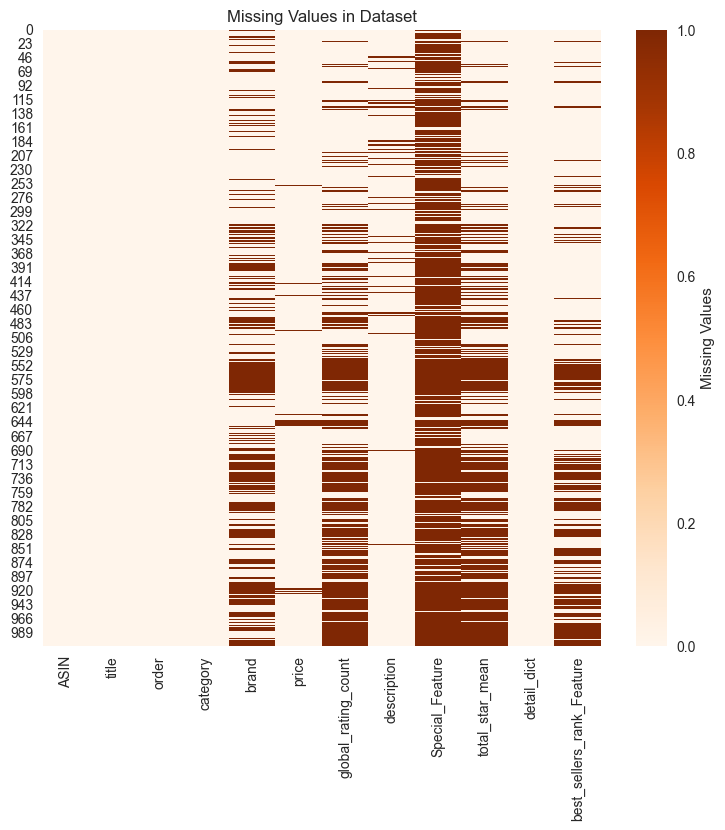

In [10]:
# 결측지 확인 및 처리
df = item_copy
print(df.isnull().sum())

plt.close()
plt.figure(figsize=(9,8))
sns.heatmap(df.isnull(), cbar_kws={'label':'Missing Values'}, cmap='Oranges')
plt.title('Missing Values in Dataset')

plt.show()

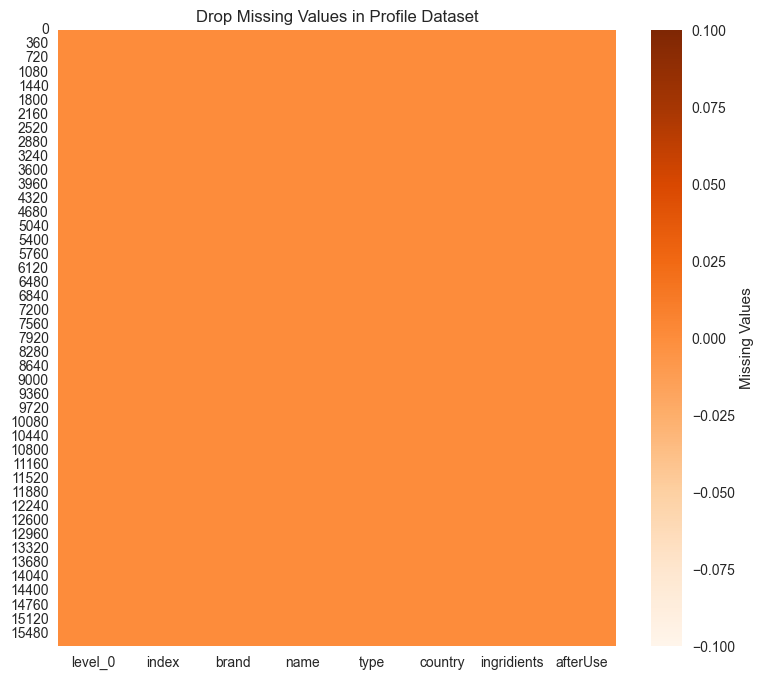

In [12]:
# 결측치 처리
skinsort_copy.dropna(subset=['country','afterUse', 'type'], inplace=True) # skinsort랑 
skinsort_copy.reset_index(inplace=True)

review_copy.dropna(inplace=True) # review_copy 는 뒤에 결측치 있으니까 불편해서, 여기서 미리 드롭하는 걸로 추가했습니다 
review_copy.reset_index(inplace=True)

# skinsort_copy.isnull().sum()

# 결측치 삭제 확인 시각화 -> 모두균일한 색으로 나오면 없는 것 !
plt.close()
plt.figure(figsize=(9,8))
sns.heatmap(skinsort_copy.isnull(), cbar_kws={'label':'Missing Values'}, cmap='Oranges')
plt.title('Drop Missing Values in Profile Dataset')
plt.show()

> 컬럼 별 전처리

In [13]:
# item_df : detail_dict 컬럼
def preprocess_detail_dict(df_copy):
    
    for i in range(len(df_copy)):
        detail_dict = ast.literal_eval(df_copy.detail_dict[i])
        
        for key, value in detail_dict.items():
            if key not in df_copy.columns:
                df_copy[key] = np.nan
            df_copy.loc[i, key] = value
            
    df_copy.drop(columns=['detail_dict'], inplace=True)
    
    return df_copy.head(2)

preprocess_detail_dict(item_copy)

,ASIN,title,order,category,brand,price,global_rating_count,description,Special_Feature,total_star_mean,best_sellers_rank_Feature,Manufacturer,Country of Origin,Product Dimensions,Is Discontinued By Manufacturer,UPC,Item model number,Department,Package Dimensions,Batteries,Date First Available,Language,Item Weight,Best Sellers Rank,Customer Reviews
0,B000BRKSAO,Alchimie Forever Rejuvenating Eye Balm | Hydra...,109,Personal Care Products,Alchimie Forever,47.00,43,2 in 1 EYE BALM: This hydrating and nourishing...,"Lightweight, Anti Aging",4.1,"#152,144 in Beauty & Personal Care (See Top 10...",Alchimie Forever,USA,2.2 x 2.2 x 4.6 inches; 1 ounces,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B000PI33IS,"K I.C.O.N. Mane Control, Hairstyling Gel. Give...",77,Hair Care Products,NaN,31.99,14,CONTAIN YOUR MANE: Add shape and definition to...,NaN,5.0,"#193,764 in Beauty & Personal Care (See Top 10...",I.C.O.N.,NaN,NaN,No,794437346182 893627000474 794437342375 9875024...,8436533670175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# item_df : best_sellers_rank 컬럼
def preprocess_best_sellers_col(df_copy):

        for i in range(len(df_copy)):
            try:
                value = df_copy.best_sellers_rank_Feature[i]
                
                if pd.isna(value): #np.nan 인 애들
                    # print(f"{i}, {df_copy.best_sellers_rank_Feature[i]} Passed")
                    continue
                
                if isinstance(value, float): # float 타입인 애들
                    value = str(value)
                    print(f"{i}, {df_copy.best_sellers_rank_Feature[i]} Passed")
                
                cat_list = df_copy.best_sellers_rank_Feature[i].split('#')
                
                df_copy.loc[i, 'Category'] = cat_list[1]
                df_copy.loc[i, 'Sub_Category'] = cat_list[2]
                
                detail_list = df_copy.Category[i].split('in')
                
                df_copy.loc[i, 'Category_Rank']= detail_list[0]
                df_copy.loc[i, 'Category_Name']= detail_list[1]
                
                df_copy.loc[i, 'Category_Name'] = df_copy.Category_Name[i].split('(')[0]
                
                sub_list = df_copy.Sub_Category[i].split('in')
                
                df_copy.loc[i, 'Sub_Category_Rank']= sub_list[0]
                df_copy.loc[i, 'Sub_Category_Name']= sub_list[1]
                    
            except Exception as e:
                print(f"{i}, {df_copy.best_sellers_rank_Feature[i]} Passed")
                print(f"Error: {e}")
                
                continue
            
        df_copy.drop(columns=['best_sellers_rank_Feature'], inplace=True)
        return df_copy.head(2)
    
preprocess_best_sellers_col(item_copy)

,ASIN,title,order,category,brand,price,global_rating_count,description,Special_Feature,total_star_mean,Manufacturer,Country of Origin,Product Dimensions,Is Discontinued By Manufacturer,UPC,Item model number,Department,Package Dimensions,Batteries,Date First Available,Language,Item Weight,Best Sellers Rank,Customer Reviews,Category,Sub_Category,Category_Rank,Category_Name,Sub_Category_Rank,Sub_Category_Name
0,B000BRKSAO,Alchimie Forever Rejuvenating Eye Balm | Hydra...,109,Personal Care Products,Alchimie Forever,47.00,43,2 in 1 EYE BALM: This hydrating and nourishing...,"Lightweight, Anti Aging",4.1,Alchimie Forever,USA,2.2 x 2.2 x 4.6 inches; 1 ounces,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"152,144 in Beauty & Personal Care (See Top 100...",30 in Eye Treatment Balms,"152,144",Beauty & Personal Care,30,Eye Treatment Balms
1,B000PI33IS,"K I.C.O.N. Mane Control, Hairstyling Gel. Give...",77,Hair Care Products,NaN,31.99,14,CONTAIN YOUR MANE: Add shape and definition to...,NaN,5.0,I.C.O.N.,NaN,NaN,No,794437346182 893627000474 794437342375 9875024...,8436533670175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"193,764 in Beauty & Personal Care (See Top 100...","2,323 in Hair Styling Gels","193,764",Beauty & Personal Care,"2,323",Hair Styl


In [15]:
# review_df : date, rating 컬럼
def preprocess_review_cols(review_copy):

    for i in range(len(review_copy)):
        
        try:
            
            if pd.isna(review_copy.date[i]) or 'on' not in review_copy.date[i]:
                # print(f"{i}, {review_copy.date[i]} Passed")
                continue
            else:
                review_copy.loc[i, 'review_date'] = review_copy.date[i].split('on')[1]
                review_copy.loc[i, 'review_date'] = pd.to_datetime(review_copy.review_date[i])
            
            if pd.isna(review_copy.review_rating[i]):
                print(f"{i}, {review_copy.review_rating[i]} Passed")
                continue
            else:
                review_copy.loc[i, 'review_rating'] = float(review_copy.review_rating[i].split('out')[0])
        except Exception as e:
            print(f"{i}, {review_copy.review_rating[i]}, Error: {e}")
            continue
        
    return review_copy.head(2)

preprocess_review_cols(review_copy)

,level_0,index,review_num,ASIN,customer_id,customer_name,title,date,review_rating,content,review_date
0,0,0,B000BRKSAO__0,B000BRKSAO,RRY2LMDB8KM5H,Mrsblue,Alchimie Forever Rejuvenating Eye Balm | Hydra...,"Reviewed in the United States on April 10, 2024",5.0,This is the best product I've ever used under ...,2024-04-10 00:00:00
1,1,1,B000BRKSAO__1,B000BRKSAO,R2KU89UAY0VLM2,Marsh Christmas,Alchimie Forever Rejuvenating Eye Balm | Hydra...,"Reviewed in the United States on June 5, 2022",5.0,Morning and night for 5 days and the dark line...,2022-06-05 00:00:00


#### Base Data

In [16]:
# item_df와 review_df를 ASIN 기준으로 merge
amazon_df = pd.merge(item_copy, review_copy, on='ASIN')

amazon_df.rename(columns={'content':'review_content', 'title_x':'title'}, inplace=True)
amazon_df.drop(['title_y'], axis=1, inplace=True)
amazon_df.reset_index(drop=True, inplace=True)
amazon_df.isnull().sum()

# Category_Rank
amazon_df['Category_Rank'] = amazon_df['Category_Rank'].apply(
    lambda x: str(x).replace(',', '') if not pd.isna(x) and isinstance(x, float) else x
).astype('str').apply(lambda x: x.replace(',', '') if x != 'nan' else None)

# Sub_Category_Rank
amazon_df['Sub_Category_Rank'] = amazon_df['Sub_Category_Rank'].apply(
    lambda x: str(x).replace(',', '') if not pd.isna(x) and isinstance(x, float) else x
).astype('str').apply(lambda x: x.replace(',', '') if x != 'nan' else None)

# review_rating
amazon_df['review_rating'] = amazon_df['review_rating'].apply(
    lambda x: str(x) if not pd.isna(x) and isinstance(x, float) else x
).astype('float', errors='ignore')

# review_date
amazon_df['review_date'] = amazon_df['review_date'].apply(
    lambda x: pd.to_datetime(x) if not pd.isna(x) else None
)

amazon_df = amazon_df[amazon_df['Country of Origin']=='Korea, Republic of']
amazon_df.reset_index(drop=True, inplace=True)

amazon_df.info()
amazon_df.head(2)
# amazon_df.to_csv(DATA_PATH + 'amazon_df_0116.csv', encoding='utf-8')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5148 entries, 0 to 5147
Data columns (total 39 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   ASIN                             5148 non-null   object        
 1   title                            5148 non-null   object        
 2   order                            5148 non-null   int64         
 3   category                         5148 non-null   object        
 4   brand                            4272 non-null   object        
 5   price                            5148 non-null   float64       
 6   global_rating_count              5148 non-null   object        
 7   description                      5048 non-null   object        
 8   Special_Feature                  1006 non-null   object        
 9   total_star_mean                  5148 non-null   float64       
 10  Manufacturer                     4977 non-null   object     

,ASIN,title,order,category,brand,price,global_rating_count,description,Special_Feature,total_star_mean,Manufacturer,Country of Origin,Product Dimensions,Is Discontinued By Manufacturer,UPC,Item model number,Department,Package Dimensions,Batteries,Date First Available,Language,Item Weight,Best Sellers Rank,Customer Reviews,Category,Sub_Category,Category_Rank,Category_Name,Sub_Category_Rank,Sub_Category_Name,level_0,index,review_num,customer_id,customer_name,date,review_rating,review_content,review_date
0,B003YUW0ZG,ATOPALM Moisturizing Hand Treatment hydrate so...,19,"Foot, Hand & Nail Care Products",ATOPALM,9.6,33,[No.1 K-Beauty Brand] No. 1 Brand Power Index ...,Lightweight,4.6,NeoPharm Co. Ltd,"Korea, Republic of",1.75 x 1.75 x 6.5 inches; 0.96 ounces,No,857811002057,22229043,Skin Care,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"121,462 in Beauty & Personal Care (See Top 100...",623 in Hand Creams & Lotions,121462,Beauty & Personal Care,623,Hand Creams & Lotions,124,124,B003YUW0ZG__0,R1609OKLLIPGJS,tngirl,"Reviewed in the United States on November 12, ...",5.0,This lotion is one of my favorites. Super mois...,2023-11-12
1,B003YUW0ZG,ATOPALM Moisturizing Hand Treatment hydrate so...,19,"Foot, Hand & Nail Care Products",ATOPALM,9.6,33,[No.1 K-Beauty Brand] No. 1 Brand Power Index ...,Lightweight,4.6,NeoPharm Co. Ltd,"Korea, Republic of",1.75 x 1.75 x 6.5 inches; 0.96 ounces,No,857811002057,22229043,Skin Care,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"121,462 in Beauty & Personal Care (See Top 100...",623 in Hand Creams & Lotions,121462,Beauty & Personal Care,623,Hand Creams & Lotions,125,125,B003YUW0ZG__1,R2PCHJMLLY1GA,mamanaka,"Reviewed in the United States on March 17, 2023",5.0,If you wash your hands frequently due to work ...,2023-03-17


#### Text preprocessing

In [21]:
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
import swifter
from deep_translator import GoogleTranslator

def detect_language(text):
    
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'

def translate_en(text):
    
    to_translate = text
    translated = GoogleTranslator(source='auto', target='english').translate(to_translate)
    
    return translated

# 리뷰 언어가 영어가 아닌 경우 -> 번역
amazon_df['detected_language'] = amazon_df['review_content'].apply(detect_language)
amazon_df.loc[amazon_df['detected_language'] != 'en', 'review_content'] = amazon_df.loc[amazon_df['detected_language'] != 'en', 'review_content'].apply(translate_en)

# amazon_df.to_csv(DATA_PATH + AMAZON / 'amazon_koreaOnly_translated.csv', encoding='utf-8')
amazon_df.rename(columns={'category':'Amazon_Category'}, inplace=True)
amazon_df['review_date'] = amazon_df['review_date'].apply(lambda x: pd.to_datetime(x) if not pd.isna(x) else None)
amazon_df['global_rating_count'] = amazon_df['global_rating_count'].astype('Int64')
amazon_df['Category_Rank'] = amazon_df['Category_Rank'].astype('Int64')
amazon_df['Sub_Category_Rank'] = amazon_df['Sub_Category_Rank'].astype('Int64')

amazon_df.head(2)

ImportError: Dask requires version '2.0.0' or newer of 'pandas' (version '1.5.3' currently installed).

In [13]:
# nltk 에서 Punkt tokenizer & stopwords list를 다운로드
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\miseu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\miseu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
# porter stemmer 초기화 및 영어 불용어 세트 생성 (캐글 참고)
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))  

# 텍스트 전처리
def clean_text(text):
    if isinstance(text, str):
    
        # 소문자로 모두 변환
        text = text.lower()

        # URL 제거
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

        # 마크다운 스타일 링크 제거
        text = re.sub(r'\[.*?\]\(.*?\)', '', text)

        # @ 제거
        text = re.sub(r'@\w+', '', text)

        # 구두점, 특수문자 제거
        text = text.translate(str.maketrans('', '', string.punctuation))

        return text
    else:
        return text

# 텍스트 토큰화
def tokenize_text(text):
    if isinstance(text, str):
        return word_tokenize(text)
    else:
        return text

# 불용어 제거
def remove_stopwords(tokens):
    if isinstance(tokens, list):
        return [word for word in tokens if word not in stop_words]
    else:
        return tokens

# -> stemming 함수 추가
def stem_tokens(tokens):
    if isinstance(tokens, list):
        return [stemmer.stem(token) for token in tokens]
    else:
        return tokens

# 저장
amazon_df['cleaned_title'] = amazon_df['title'].apply(clean_text)
amazon_df['cleaned_review'] = amazon_df['review_content'].apply(clean_text)
skinsort_copy['cleaned_ingridients'] = skinsort_copy['ingridients'].apply(clean_text)
skinsort_copy['cleaned_afterUse'] = skinsort_copy['afterUse'].apply(clean_text)

amazon_df['tokenized_title'] = amazon_df['cleaned_title'].apply(tokenize_text)
amazon_df['tokenized_review'] = amazon_df['cleaned_review'].apply(tokenize_text)
skinsort_copy['tokenized_ingridients'] = skinsort_copy['cleaned_ingridients'].apply(tokenize_text)
skinsort_copy['tokenized_afterUse'] = skinsort_copy['cleaned_afterUse'].apply(tokenize_text)

amazon_df['stemmed_title'] = amazon_df['tokenized_title'].apply(stem_tokens)
amazon_df['stemmed_review'] = amazon_df['tokenized_review'].apply(stem_tokens) 
skinsort_copy['stemmed_ingridients'] = skinsort_copy['tokenized_ingridients'].apply(stem_tokens)
skinsort_copy['stemmed_afterUse'] = skinsort_copy['tokenized_afterUse'].apply(stem_tokens)

amazon_df['stpw_processed_title'] = amazon_df['tokenized_title'].apply(remove_stopwords)
amazon_df['stpw_processed_review'] = amazon_df['tokenized_review'].apply(remove_stopwords)
skinsort_copy['stpw_processed_ingridients'] = skinsort_copy['tokenized_ingridients'].apply(remove_stopwords)
skinsort_copy['stpw_processed_afterUse'] = skinsort_copy['tokenized_afterUse'].apply(remove_stopwords)

amazon_df.head(2)

,ASIN,title,order,Amazon_Category,brand,price,global_rating_count,description,Special_Feature,total_star_mean,Manufacturer,Country of Origin,Product Dimensions,Is Discontinued By Manufacturer,UPC,Item model number,Department,Package Dimensions,Batteries,Date First Available,Language,Item Weight,Best Sellers Rank,Customer Reviews,Category,Sub_Category,Category_Rank,Category_Name,Sub_Category_Rank,Sub_Category_Name,index,review_num,customer_id,customer_name,date,review_rating,review_content,review_date,detected_language,cleaned_title,cleaned_review,tokenized_title,tokenized_review,stemmed_title,stemmed_review,stpw_processed_title,stpw_processed_review
0,B003YUW0ZG,ATOPALM Moisturizing Hand Treatment hydrate so...,19,"Foot, Hand & Nail Care Products",ATOPALM,9.6,33,[No.1 K-Beauty Brand] No. 1 Brand Power Index ...,Lightweight,4.6,NeoPharm Co. Ltd,"Korea, Republic of",1.75 x 1.75 x 6.5 inches; 0.96 ounces,No,857811002057,22229043,Skin Care,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"121,462 in Beauty & Personal Care (See Top 100...",623 in Hand Creams & Lotions,121462,Beauty & Personal Care,623,Hand Creams & Lotions,124,B003YUW0ZG__0,R1609OKLLIPGJS,tngirl,"Reviewed in the United States on November 12, ...",5.0,This lotion is one of my favorites. Super mois...,2023-11-12,en,atopalm moisturizing hand treatment hydrate so...,this lotion is one of my favorites super moist...,"[atopalm, moisturizing, hand, treatment, hydra...","[this, lotion, is, one, of, my, favorites, sup...","[atopalm, moistur, hand, treatment, hydrat, so...","[thi, lotion, is, one, of, my, favorit, super,...","[atopalm, moisturizing, hand, treatment, hydra...","[lotion, one, favorites, super, moisturizing, ..."
1,B003YUW0ZG,ATOPALM Moisturizing Hand Treatment hydrate so...,19,"Foot, Hand & Nail Care Products",ATOPALM,9.6,33,[No.1 K-Beauty Brand] No. 1 Brand Power Index ...,Lightweight,4.6,NeoPharm Co. Ltd,"Korea, Republic of",1.75 x 1.75 x 6.5 inches; 0.96 ounces,No,857811002057,22229043,Skin Care,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"121,462 in Beauty & Personal Care (See Top 100...",623 in Hand Creams & Lotions,121462,Beauty & Personal Care,623,Hand Creams & Lotions,125,B003YUW0ZG__1,R2PCHJMLLY1GA,mamanaka,"Reviewed in the United States on March 17, 2023",5.0,If you wash your hands frequently due to work ...,2023-03-17,en,atopalm moisturizing hand treatment hydrate so...,if you wash your hands frequently due to work ...,"[atopalm, moisturizing, hand, treatment, hydra...","[if, you, wash, your, hands, frequently, due, ...","[atopalm, moistur, hand, treatment, hydrat, so...","[if, you, wash, your, hand, frequent, due, to,...","[atopalm, moisturizing, hand, treatment, hydra...","[wash, hands, frequently, due, work, germphobi..."


# PART 2: EDA

### ◼ Amazon

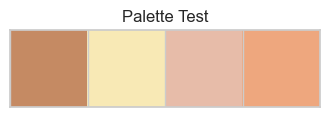

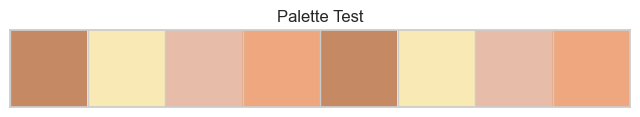

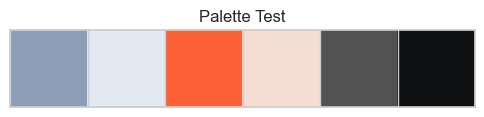

In [15]:
from matplotlib.colors import LinearSegmentedColormap
from itertools import cycle

beauty_palette = ['#C58A63', '#F8E9B5', '#E7BCA9', '#EEA77E']
market_palette = ["#003f5c", "#214876", "#4e4c8a", "#7e4a93", "#ae448d", "#d63e7a", "#f1465d", "#fd6036"]
market_palette =  [color for color, _ in zip(cycle(beauty_palette), range(len(market_palette)))]

skin_palette = ['#8C9DB7', '#E3E9F2', '#FD6036','#F6DDD3', '#525252', '#0E1012']
custom_cmap = LinearSegmentedColormap.from_list("custom_palette", market_palette)

sns.palplot(beauty_palette)
plt.title("Palette Test")
plt.show()

sns.palplot(market_palette)
plt.title("Palette Test")
plt.show()

sns.palplot(skin_palette)
plt.title("Palette Test")
plt.show()

> K-beauty 하위 카테고리 및 브랜드 구성 확인

In [16]:
# K-beauty 하위 카테고리 별 개수
ak_category_count = pd.DataFrame(amazon_df.Amazon_Category.value_counts())
ak_category_count.reset_index(inplace=True)
ak_category_count.columns = ['Amazon_Category', 'Count']
print(ak_category_count.head())

# K-beauty 아이템 별 개수
category_count = pd.DataFrame(amazon_df.Sub_Category_Name.value_counts())
category_count.reset_index(inplace=True)
category_count.columns = ['Sub_Category', 'Count']
print(category_count.head())

                   Amazon_Category  Count
0           Personal Care Products   2635
1                           Makeup    846
2               Skin Care Products    673
3  Foot, Hand & Nail Care Products    398
4       Beauty Tools & Accessories    302
                Sub_Category  Count
0              Facial Serums    860
1          Face Moisturizers    590
2               Facial Masks    468
3       Facial Toners & Astr    312
4   Manicure & Pedicure Kits    221


In [17]:
# K-beauty 브랜드 별 개수 (상품 수로 추정 또는 상품 수는 직접 사이트 들어가서 눌러보고 ㅎ 컬럼 별로 입력)
amazon_df.brand.unique()

# 브랜드 별 리뷰 개수 (상위 30개)
k_brand_count = pd.DataFrame(amazon_df.brand.value_counts().head(31))
k_brand_count.reset_index(inplace=True)
k_brand_count.columns = ['brand', 'count']
k_brand_count.drop(0, axis=0, inplace=True)
k_brand_count.head()

,brand,count
1,Three Seven (777),205
2,PURITO,143
3,SNP Shining Nature Purity,138
4,Dr.G,137
5,beplain,115


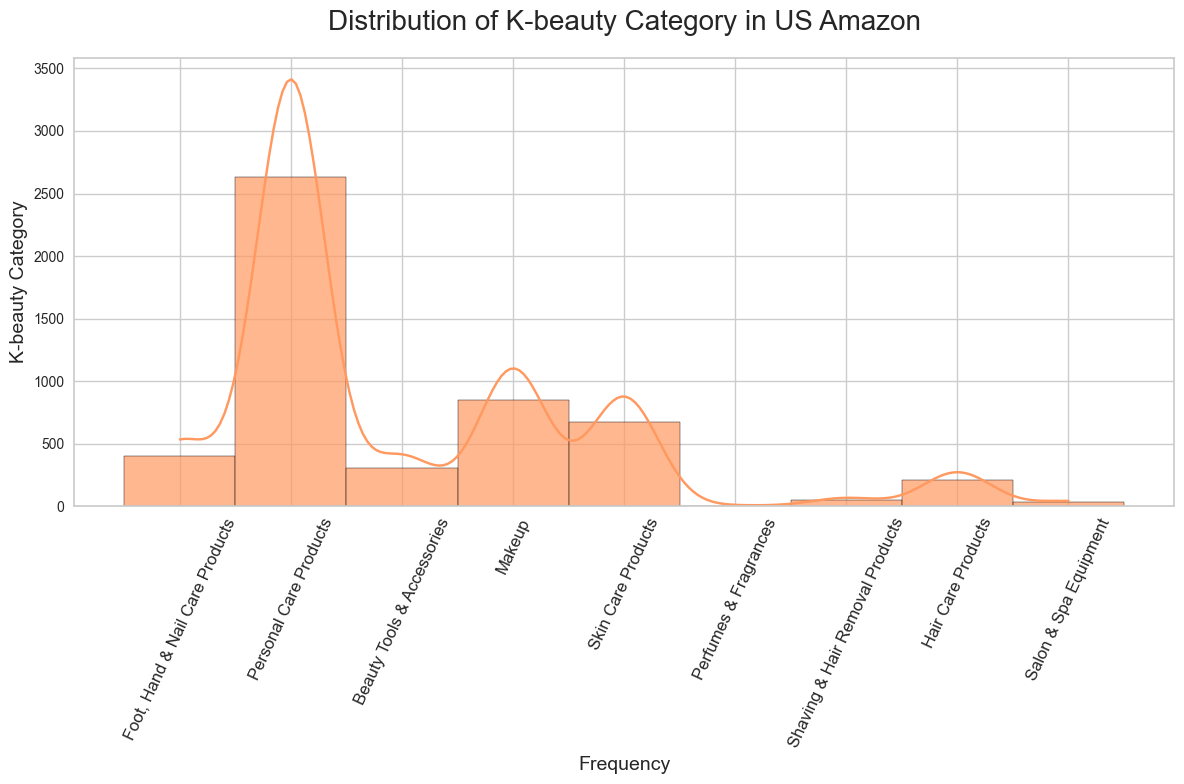

In [18]:
# 카테고리 분포
plt.figure(figsize=(12,8))
sns.histplot(data=amazon_df['Amazon_Category'], bins=31, alpha=0.7, color='#FF9960', kde=True)
plt.title('Distribution of K-beauty Category in US Amazon', fontsize=20, pad=20)

plt.xticks(rotation=65, fontsize=12)
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('K-beauty Category', fontsize=14)

plt.tight_layout()
plt.show()

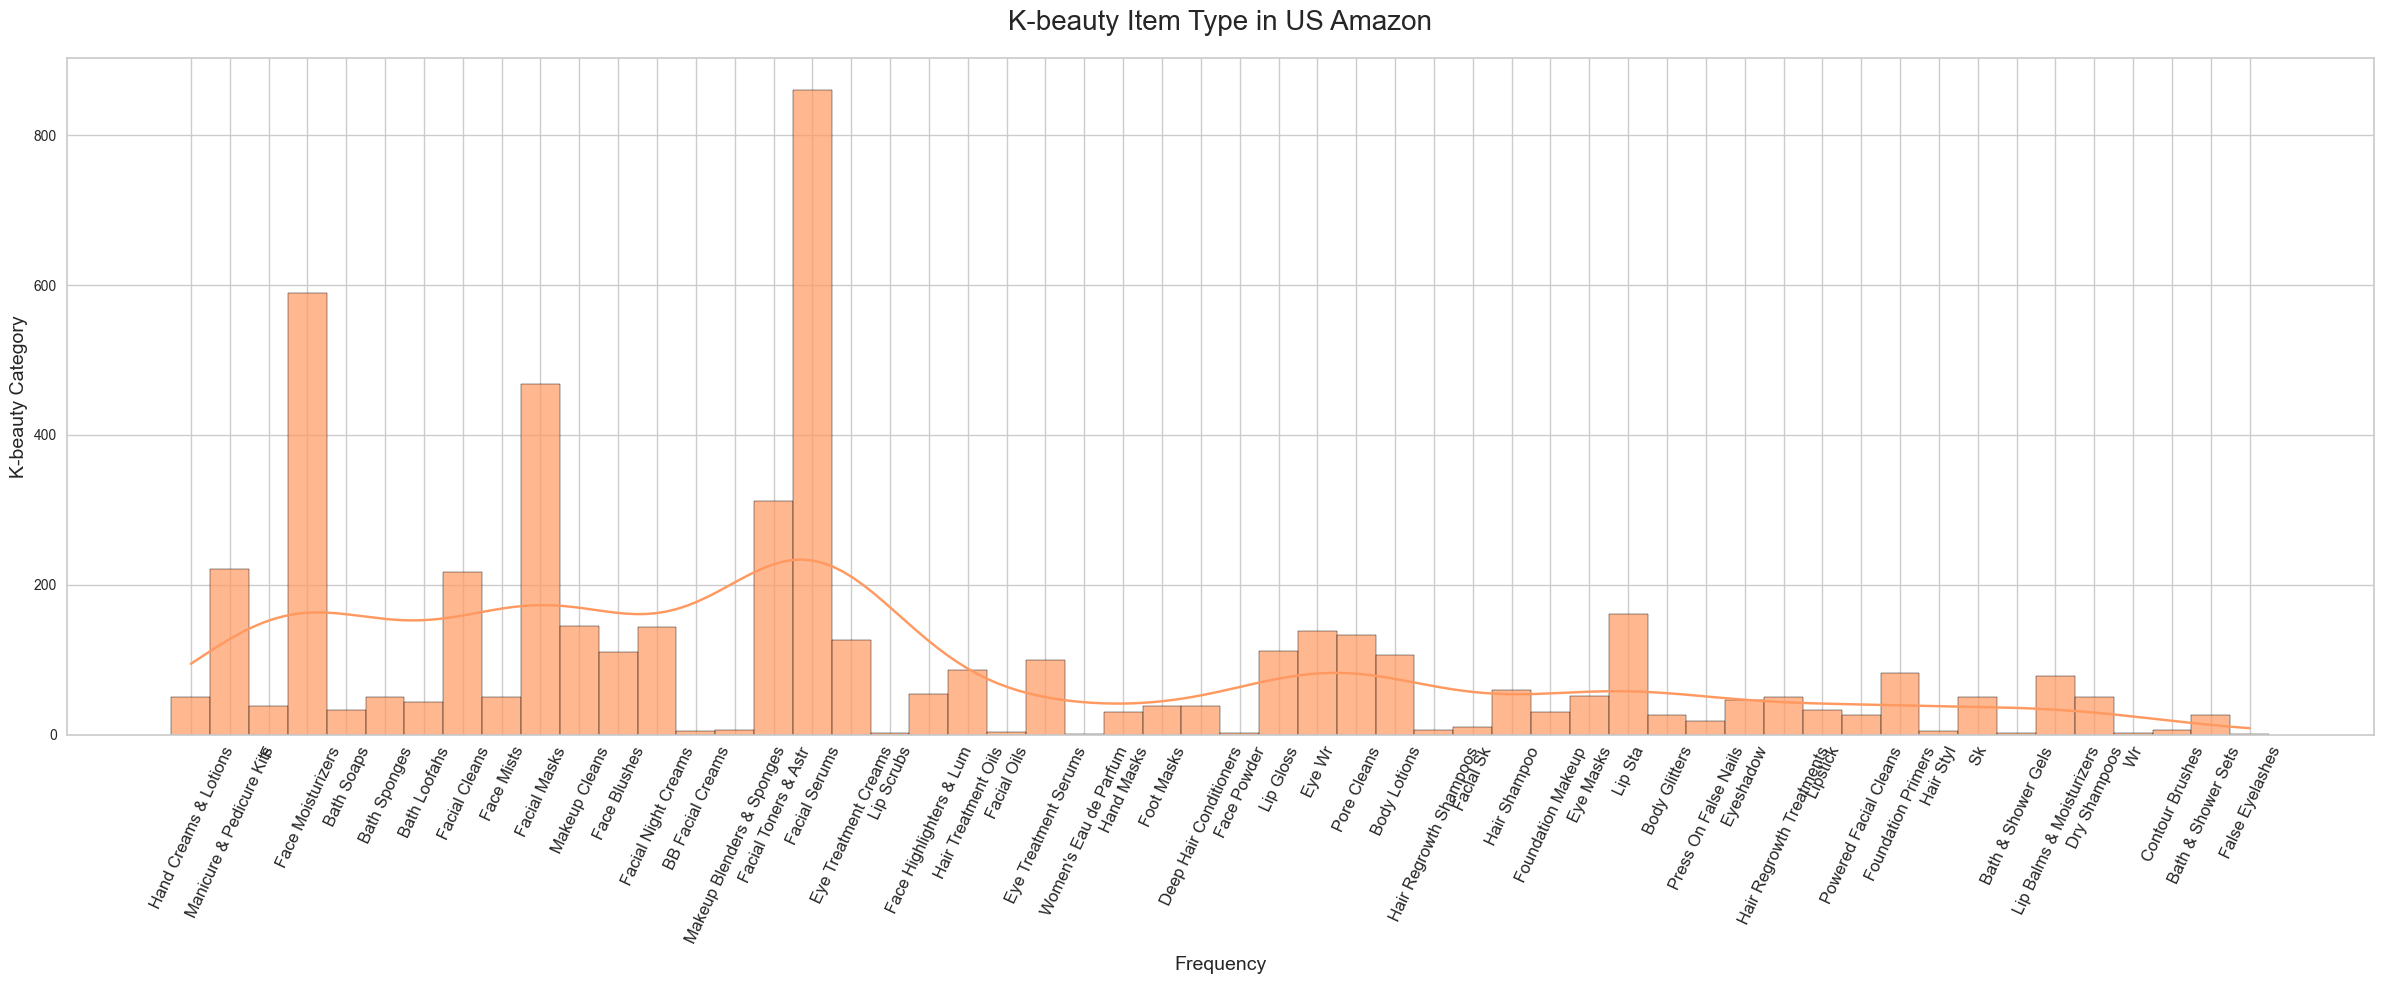

In [19]:
# 제품 유형 분포
plt.figure(figsize=(24,10))
sns.histplot(data=amazon_df['Sub_Category_Name'], bins=31, alpha=0.7, color='#FF9960', kde=True)
plt.title('K-beauty Item Type in US Amazon', fontsize=20, pad=20)

plt.xticks(rotation=65, fontsize=12)
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('K-beauty Category', fontsize=14)

plt.tight_layout()
plt.show()

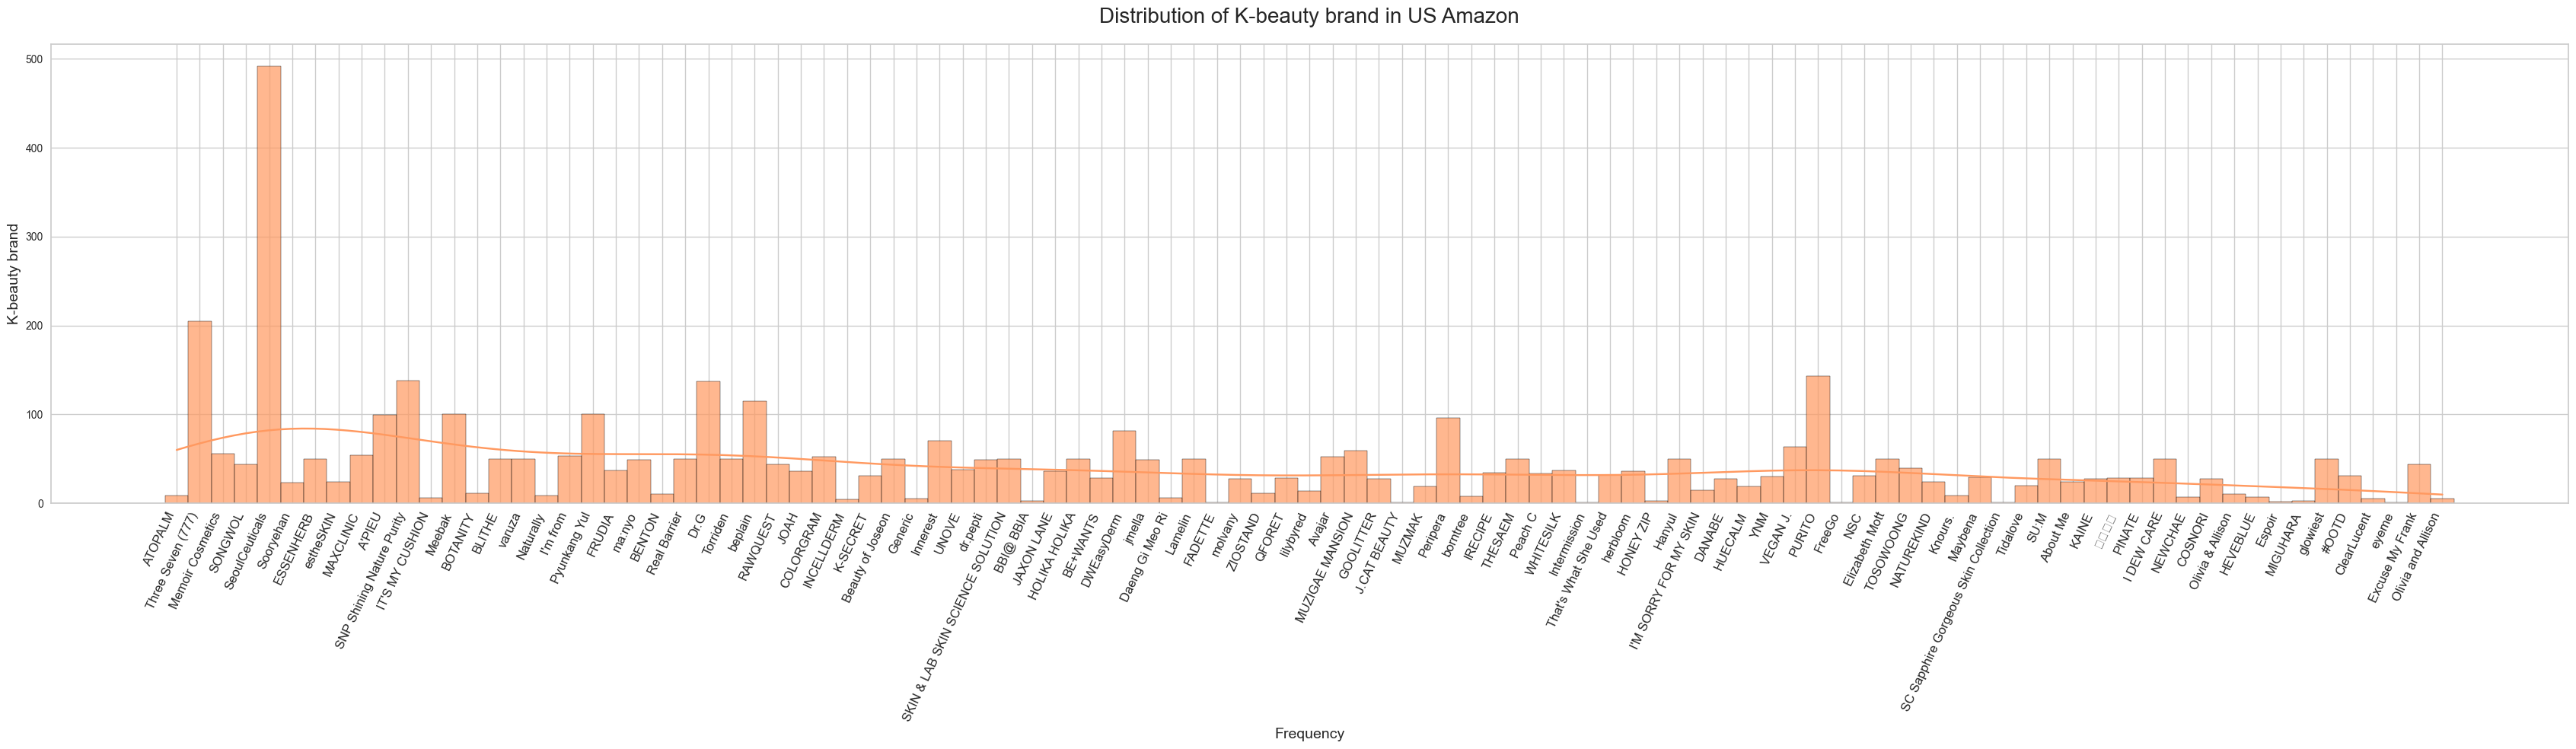

In [20]:
# 브랜드 분포
plt.figure(figsize=(34,10))
sns.histplot(data=amazon_df, x='brand', color='#FF9960', alpha=0.7, kde=True)
plt.title('Distribution of K-beauty brand in US Amazon', fontsize=20, pad=20)

plt.xticks(rotation=65, fontsize=12, ha='right')
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('K-beauty brand', fontsize=14)

plt.tight_layout()
plt.show()

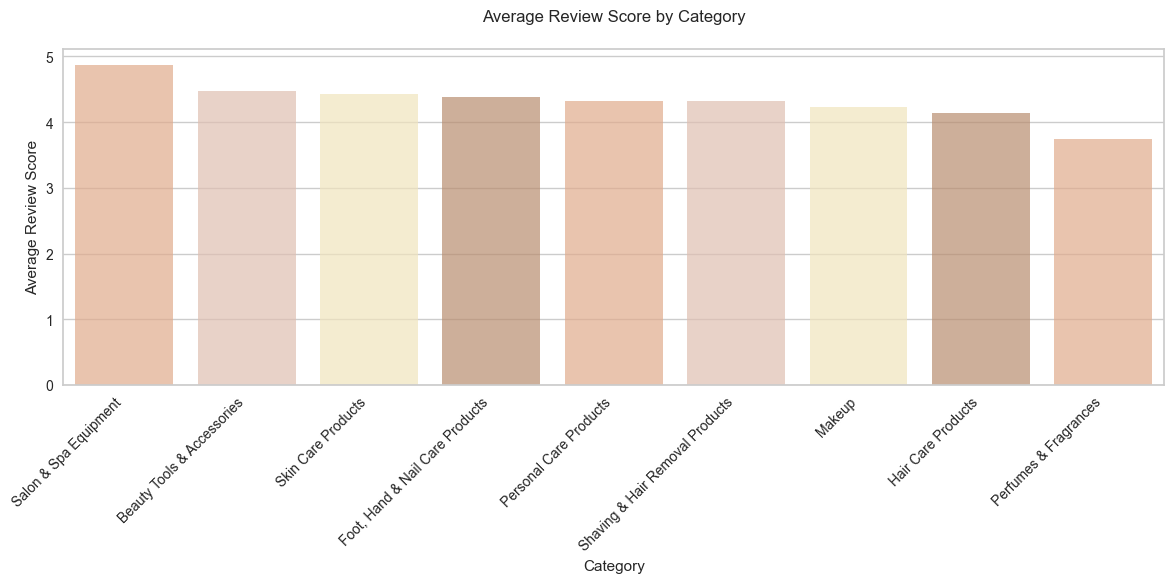

In [21]:
# <카테고리, 제품 유형, 브랜드 별 <-> 리뷰 평점 확인>
# 1. 카테고리별 평균 리뷰 평점
category_mean = pd.pivot_table(amazon_df, index=['Amazon_Category'], values='review_rating',aggfunc='mean')
category_mean = category_mean.reset_index().sort_values(by='review_rating', ascending=False)
category_mean.head(2)

plt.figure(figsize=(12, 6))
sns.barplot(data=category_mean, x='Amazon_Category', y='review_rating', dodge=False, palette=market_palette[-1::-1], alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.title('Average Review Score by Category', pad=20)
plt.ylabel('Average Review Score')
plt.xlabel('Category')
plt.tight_layout()
plt.show()

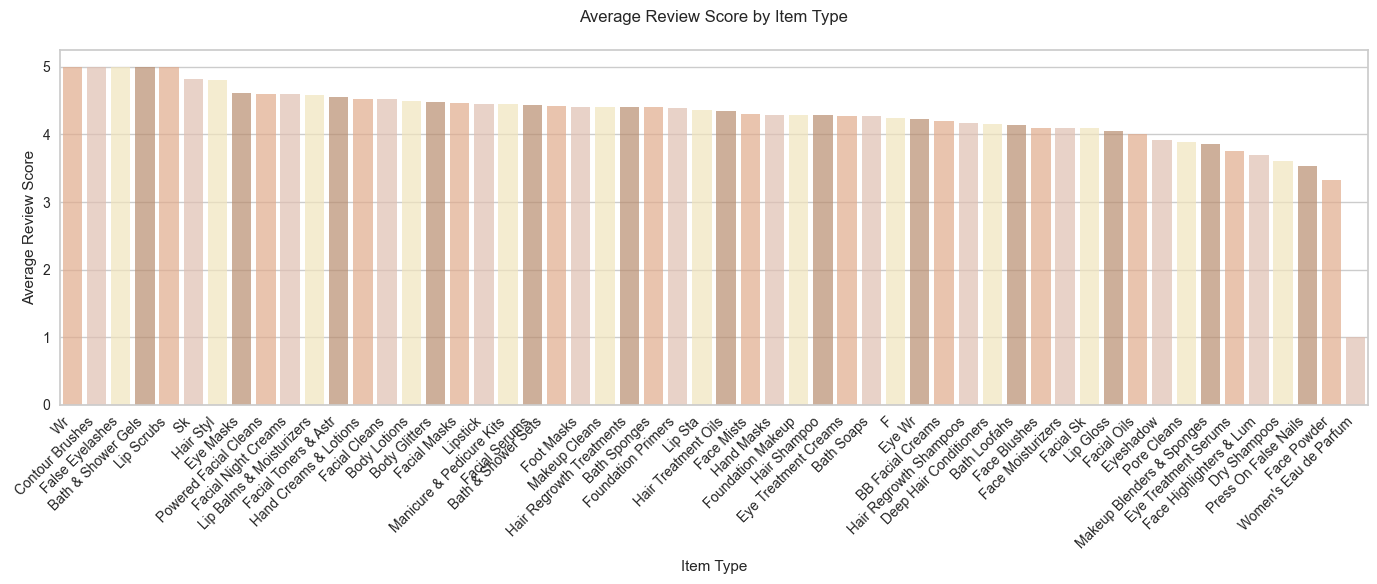

In [22]:
# <카테고리, 제품 유형, 브랜드 별 <-> 리뷰 평점 확인>
# 1-2. 제품 유형 별 평균 리뷰 평점
category_mean = pd.pivot_table(amazon_df, index=['Sub_Category_Name'], values='review_rating',aggfunc='mean')
category_mean = category_mean.reset_index().sort_values(by='review_rating', ascending=False)
category_mean.head(2)

plt.figure(figsize=(14, 6))
sns.barplot(data=category_mean, x='Sub_Category_Name', y='review_rating', dodge=False, palette=market_palette[-1::-1], alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.title('Average Review Score by Item Type', pad=20)
plt.ylabel('Average Review Score')
plt.xlabel('Item Type')
plt.tight_layout()
plt.show()

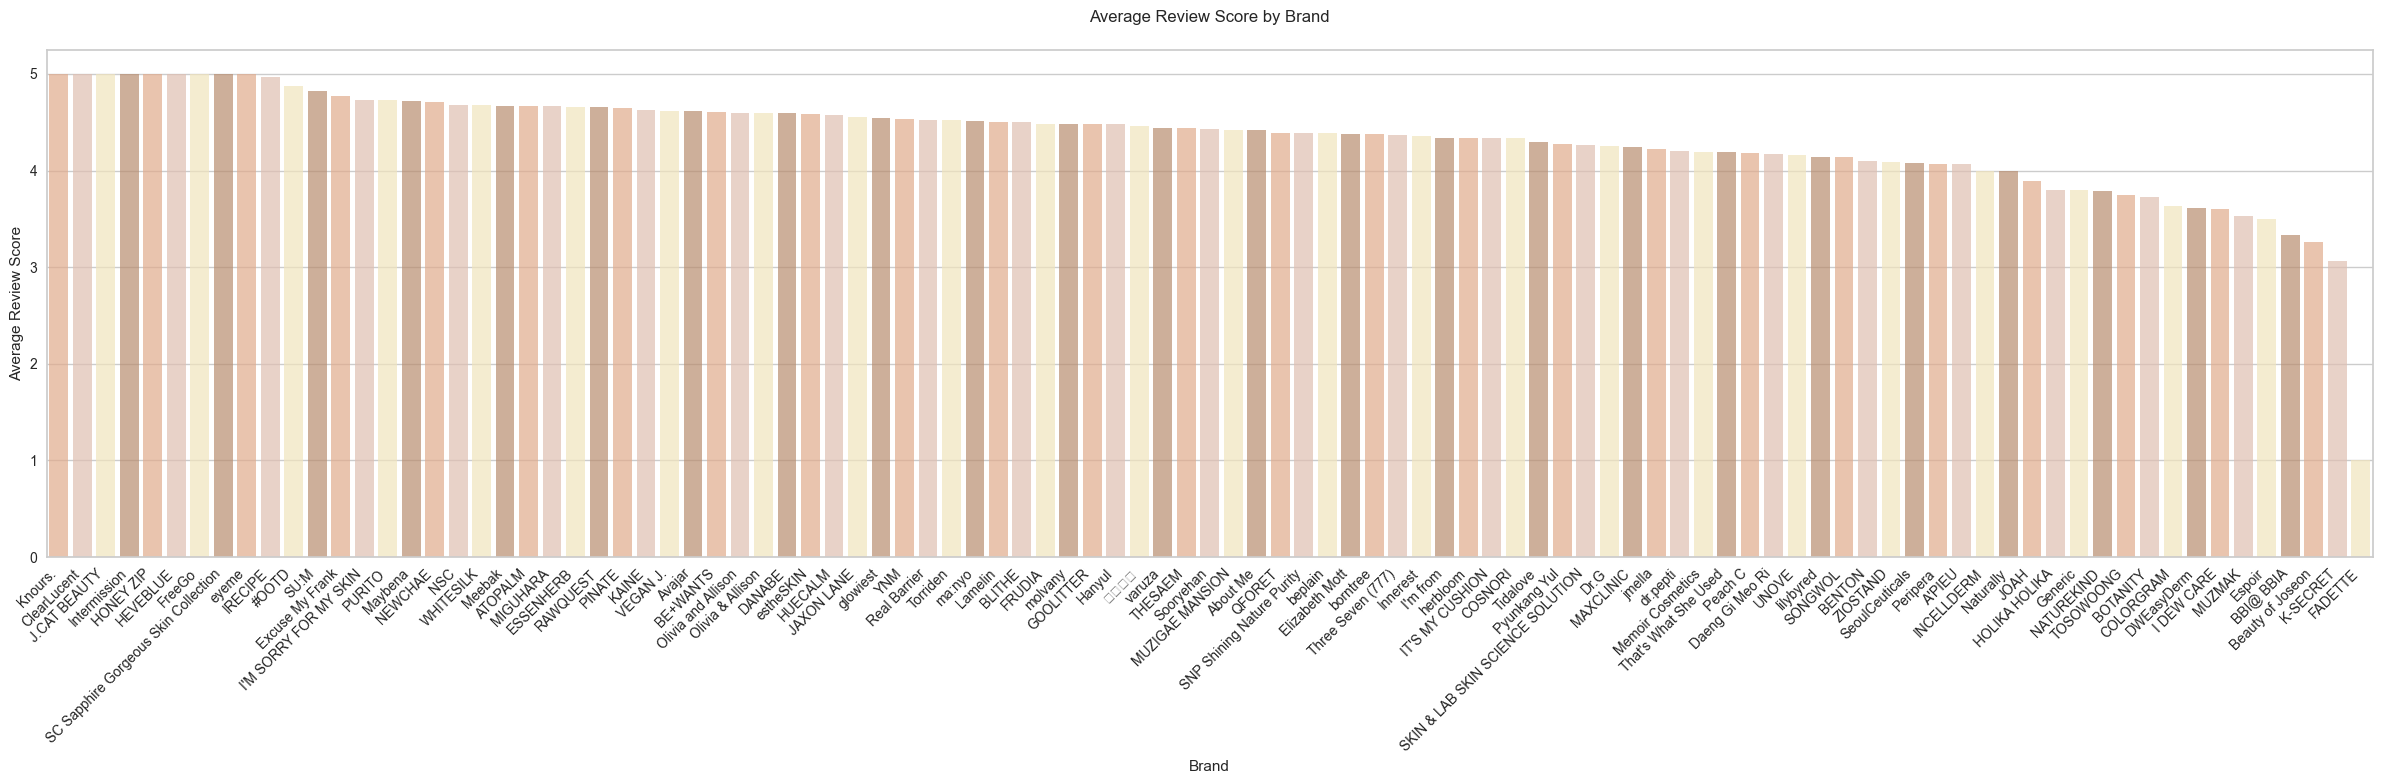

In [23]:
# 2. 브랜드별 평균 리뷰 평점
filtered_df = amazon_df[['brand', 'review_rating']].copy()

filtered_df['review_rating'] = pd.to_numeric(filtered_df['review_rating'], errors='coerce')
filtered_df.dropna(subset=['brand', 'review_rating'], inplace=True)

brand_review_score = pd.pivot_table(
    filtered_df,
    index=['brand'],
    values='review_rating',
    aggfunc='mean'
)
brand_review_score = brand_review_score.reset_index().sort_values(by='review_rating', ascending=False)
brand_review_score.reset_index(inplace=True, drop=True)
brand_review_score[:20]

brand_review_score.head(2)

plt.figure(figsize=(24, 8))
sns.barplot(data=brand_review_score, x='brand', y='review_rating', dodge=False, palette=market_palette[-1::-1], alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.title('Average Review Score by Brand', pad=20)
plt.ylabel('Average Review Score')
plt.xlabel('Brand')
plt.tight_layout()
plt.show()

In [24]:
# # K-beauty 하위 카테고리와 브랜드 별 리뷰 평점 평균 시각화
# import itertools
# plt.close()

# num_bars = 54
# extended_palette = list(itertools.islice(itertools.cycle(market_palette), num_bars))

# fig, axes = plt.subplots(2, 1, figsize=(34, 10), sharex=False)

# # 1. 카테고리별 Sub-Category 평점 평균
# sns.barplot(
#     data=category_mean, 
#     x='Sub_Category_Name', 
#     y='review_rating', 
#     hue='Category_Name', 
#     dodge=False, 
#     palette=extended_palette, 
#     ax=axes[0]
# )
# axes[0].set_title('Average Review Ratings by Sub-Category')
# axes[0].set_ylabel('Average Rating')
# axes[0].set_xlabel('Sub-Category')
# axes[0].tick_params(axis='x', rotation=45)
# axes[0].legend(title='Category Name')

# # 2. 브랜드별 평점 평균
# sns.barplot(
#     data=brand_review_score, 
#     x='brand', 
#     y='review_rating', 
#     palette=extended_palette, 
#     ax=axes[1]
# )
# axes[1].set_title('Average Review Ratings by Brand')
# axes[1].set_ylabel('Average Rating')
# axes[1].set_xlabel('Brand')
# axes[1].tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

In [25]:
import plotly.graph_objects as go

df = brand_review_score.head(30)

fig = go.Figure(data=[go.Table(
    header=dict(values=df.columns, fill_color='paleturquoise', align='center'),
    cells=dict(values=[df[col] for col in df.columns], fill_color='lavender', align='center'))
])

fig.update_layout(title='Brand Review Scores')
fig.show()

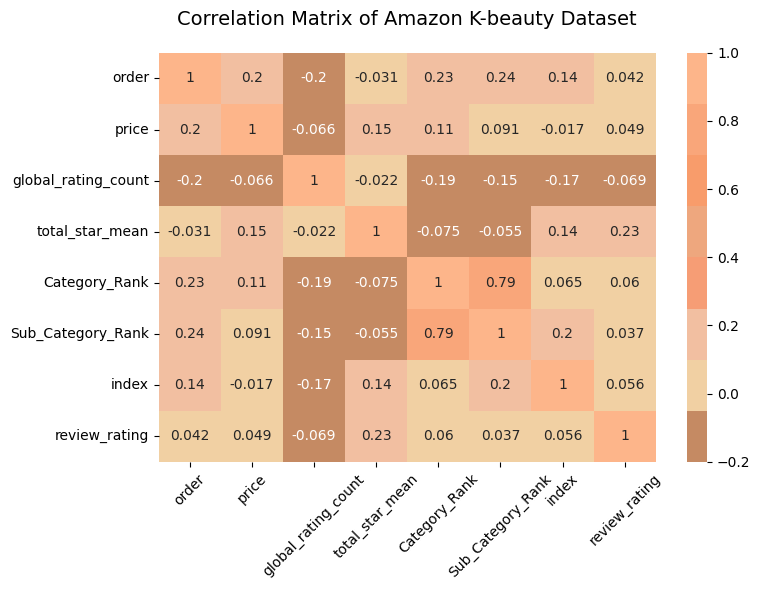

In [26]:
# 전반적인 상관관계
ordinal_palette = [
    '#C58A63', 
    '#F1D0A3', 
    '#F2BFA1',  
    '#F69D75',  
    '#EEA77E',  
    '#F89C6B',  
    '#F9A67A',  
    '#FDB58A'
]

plt.close()

sns.reset_defaults()
plt.rcdefaults()
plt.style.use('default')
plt.figure(figsize=(8,6))

sample_data = amazon_df.select_dtypes(include=["number"])

#compute correlation
corr_matrix = sample_data.corr()
corr_matrix

#annot=True return the correlation values
sns.heatmap(corr_matrix, cmap=ordinal_palette, annot=True)
plt.xticks(rotation=45)
plt.title('Correlation Matrix of Amazon K-beauty Dataset', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

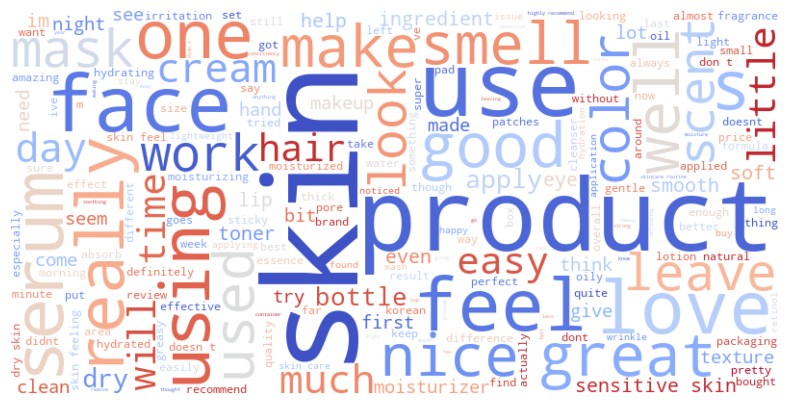

In [27]:
from wordcloud import WordCloud

# 전처리된 아마존 모든 리뷰 워드 클라우드
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(amazon_df['cleaned_review'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Review")
plt.show()

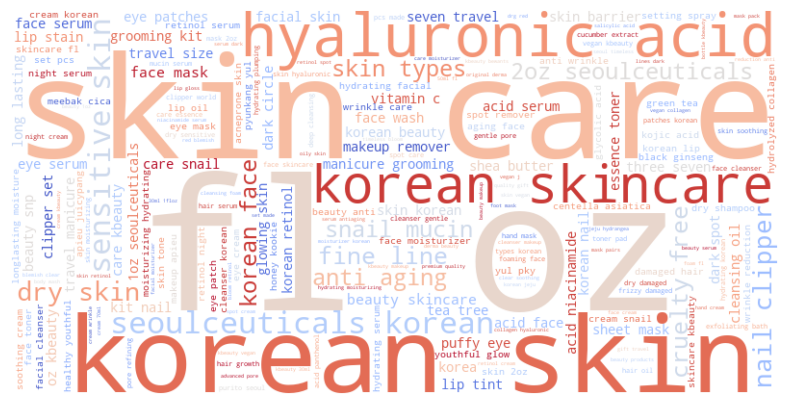

In [28]:
# 전처리된 상품 제목 (아이템 이름) 워드 클라우드
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(amazon_df['cleaned_title'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Title")
plt.show()

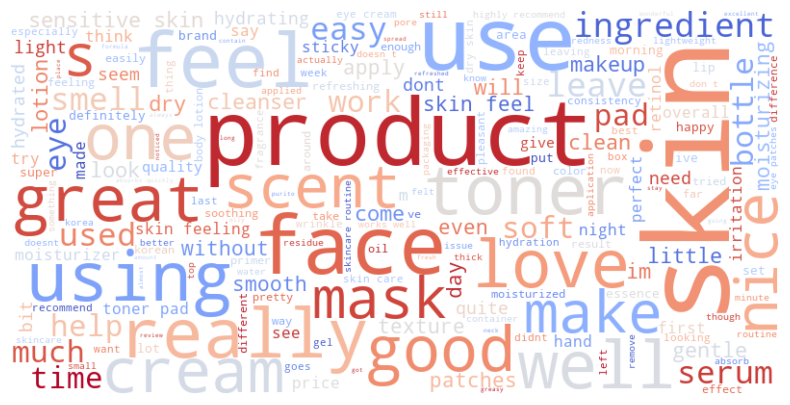

In [29]:
# top 30 브랜드 (평점 기준도 확인 필요) - 리뷰 내용 워드 클라우드
top30_brand_list = brand_review_score['brand'].head(30).tolist()
query_cond = amazon_df['brand'].isin(top30_brand_list)
top_df = amazon_df[query_cond]

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(top_df['cleaned_review'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Title")
plt.show()

### ◼ Skinsort

In [30]:
import plotly.express as px
import plotly.io as pio

df = skinsort_copy

country_dist = df['country'].value_counts().reset_index()
country_dist.columns = ['Country', 'Count']

fig = px.pie(country_dist[:15], values='Count', names='Country', title=f"Country Distribution for Skinsort Brand Data")
fig.update_traces(hole=.3)
# imgname = "skinsort_country_distribution.png"
# fig.write_image(DATA_PATH+imgname)
fig.show()

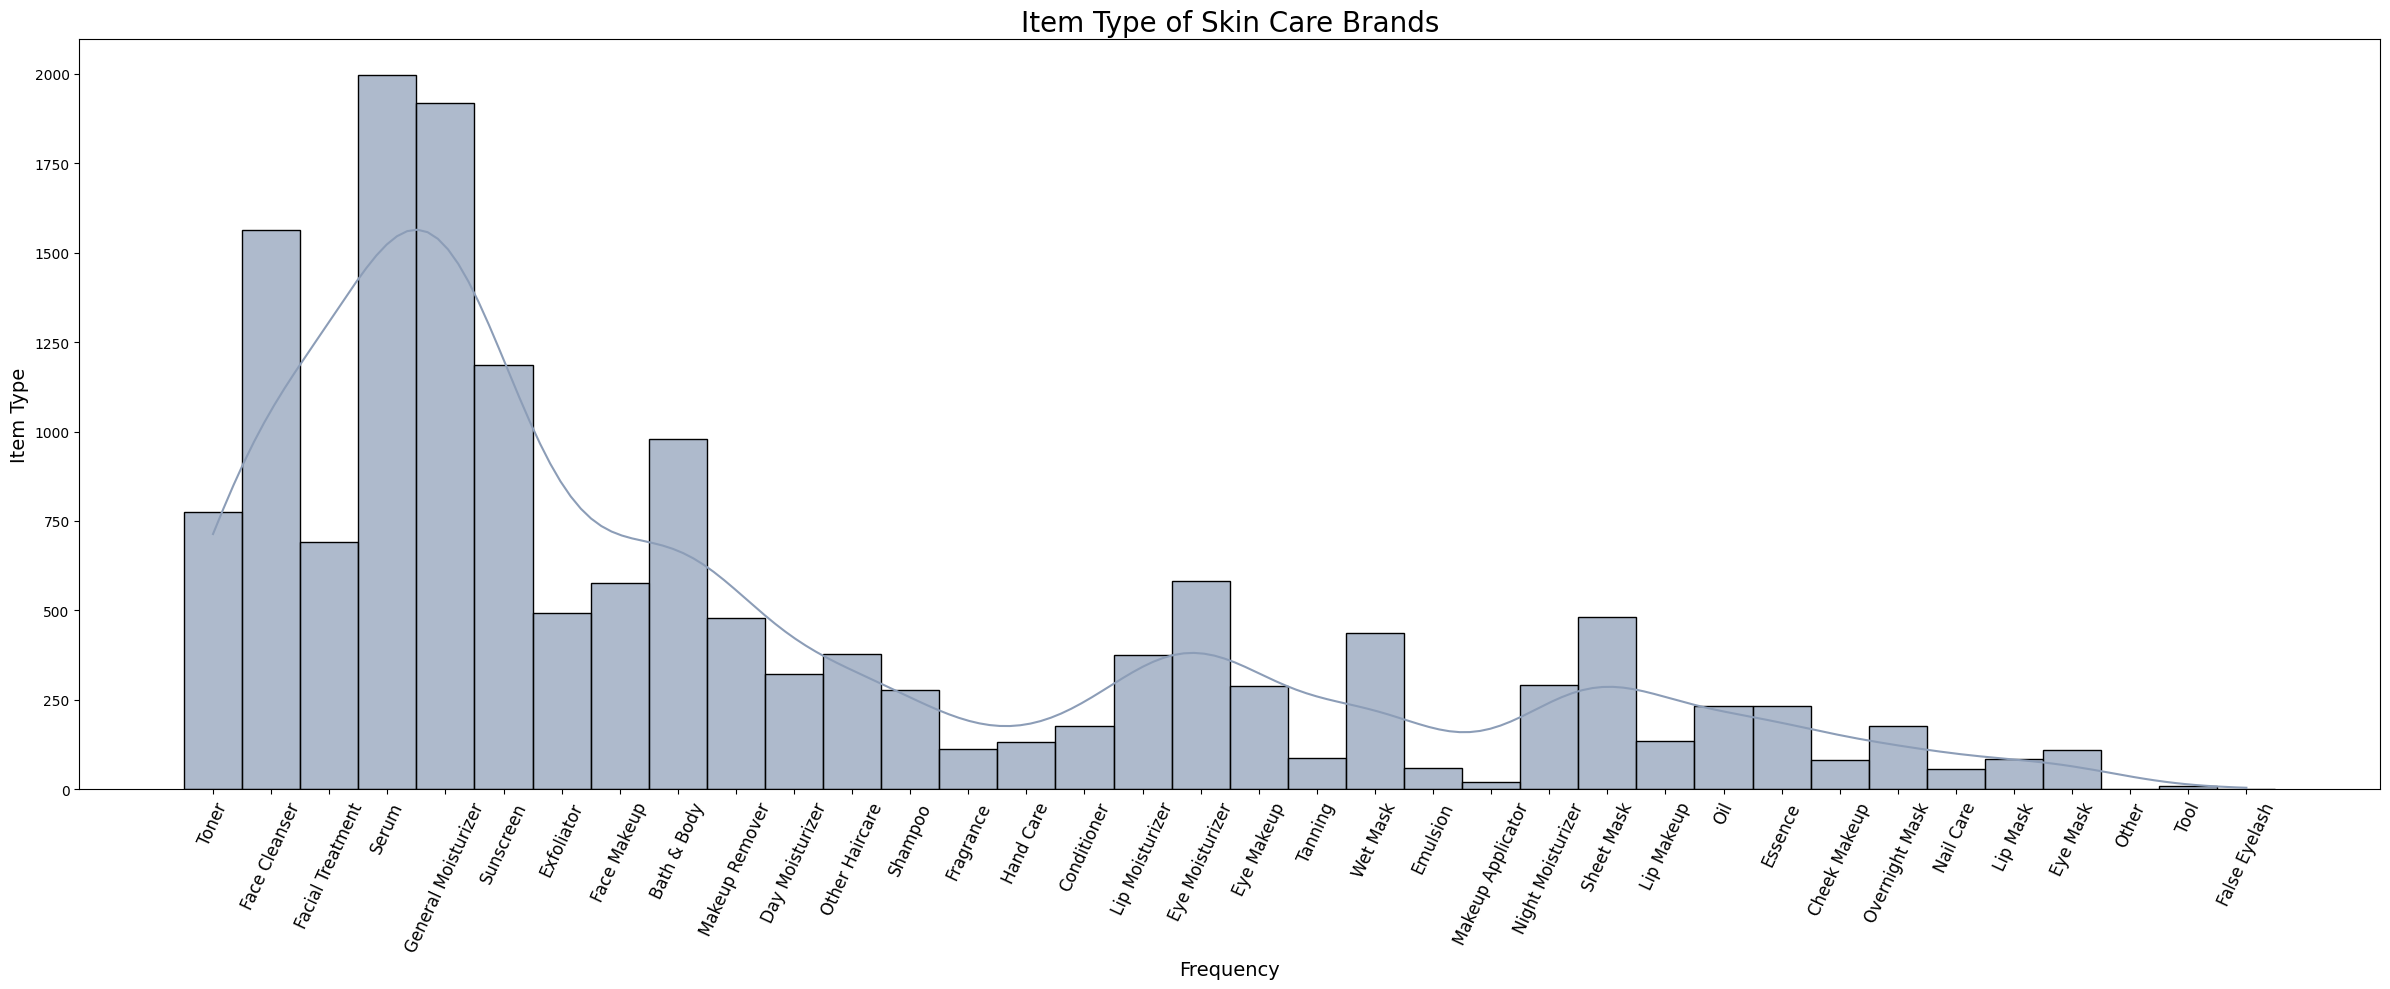

In [31]:
# 카테고리 분포
plt.figure(figsize=(24,10))
sns.histplot(data=skinsort_copy['type'], bins=31, alpha=0.7, color='#8C9DB7', kde=True)
plt.title('Item Type of Skin Care Brands', fontsize=20)

plt.xticks(rotation=65, fontsize=12)
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('Item Type', fontsize=14)

plt.tight_layout()
plt.show()

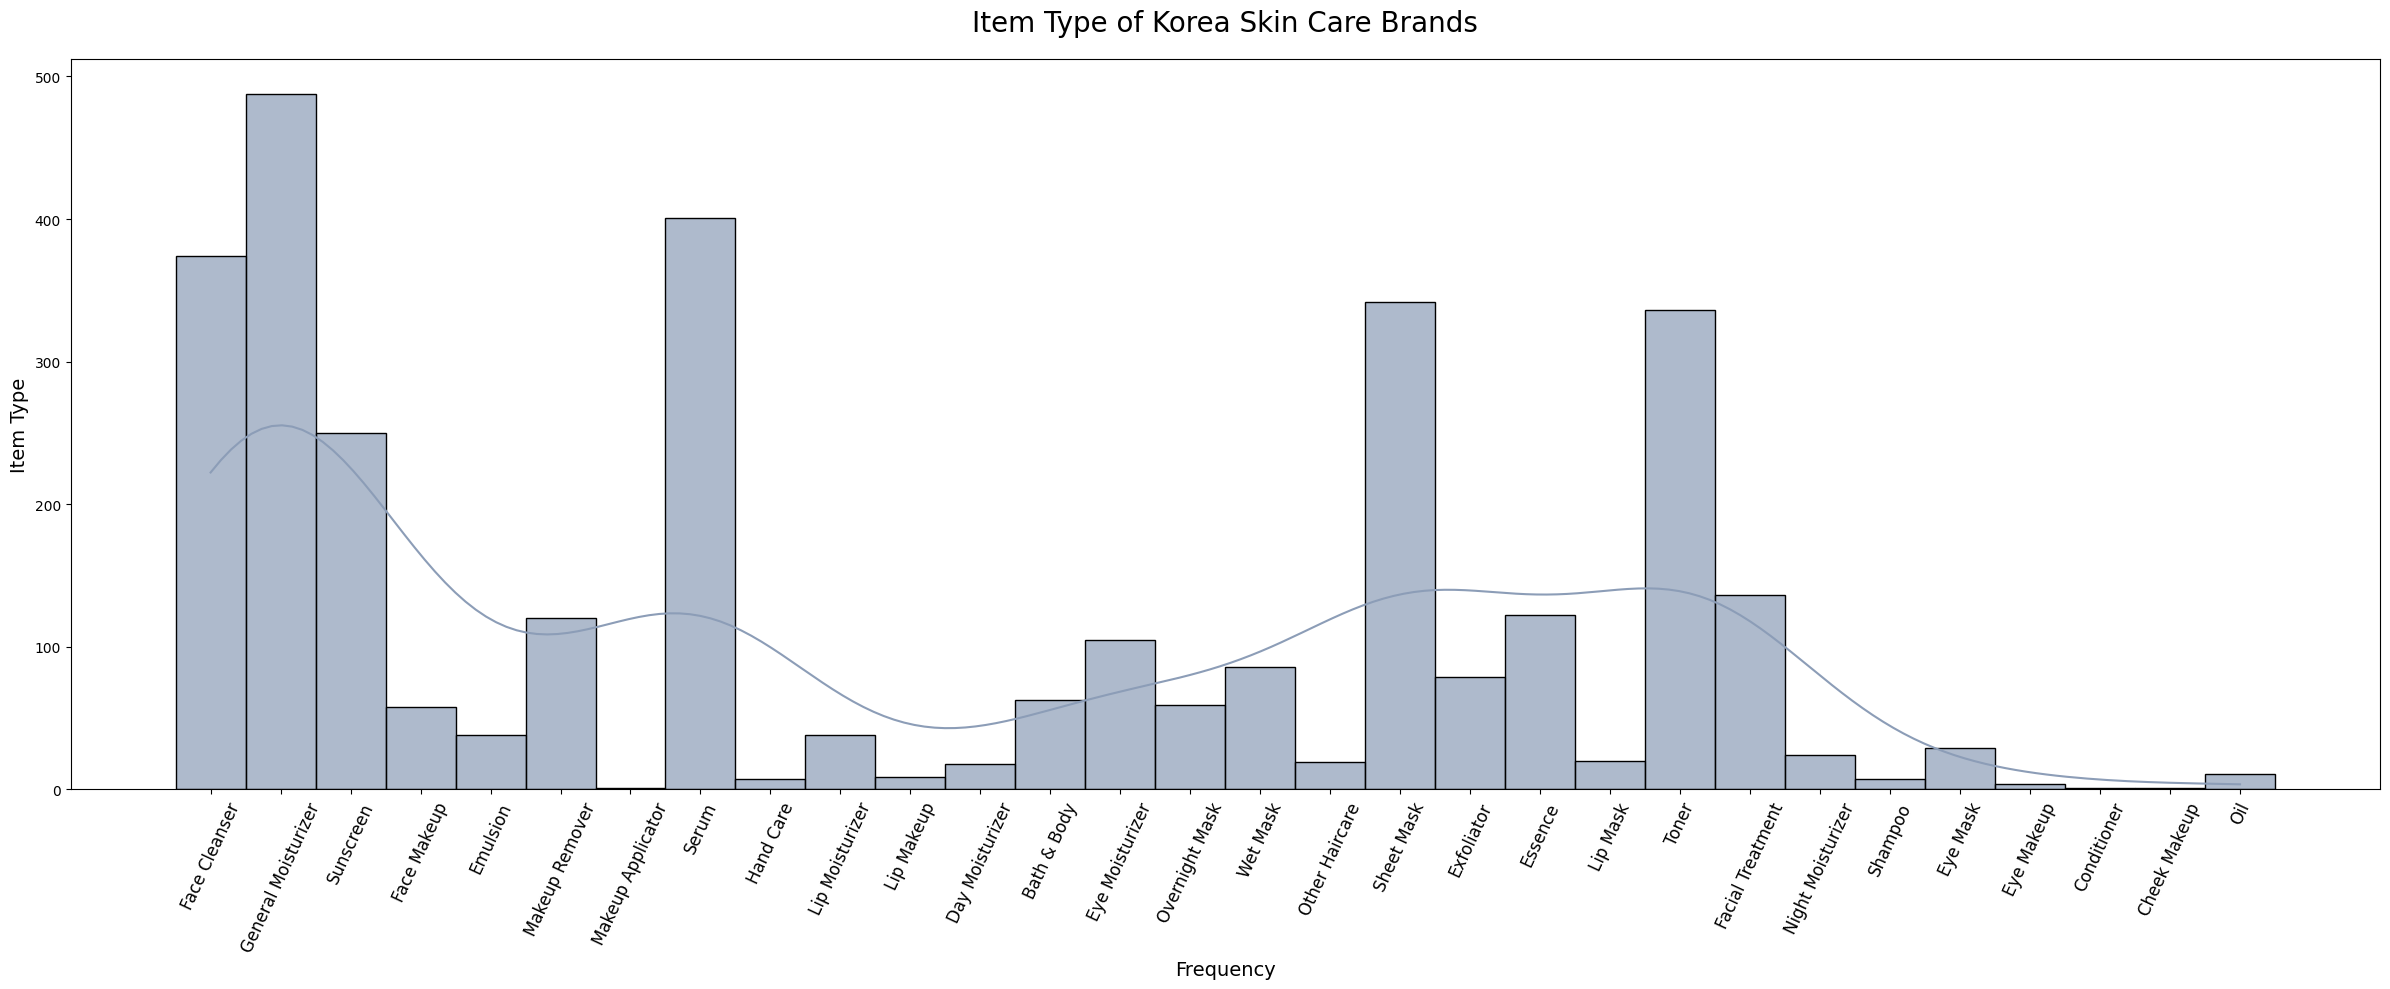

In [32]:
# 한국 스킨케어 브랜드들의 제품 타입 분포
query_cond = "country == 'South Korea'"
k_skin_brand = skinsort_copy.query(query_cond).reset_index()
k_skin_brand.drop(columns='index', inplace=True)
k_skin_brand.head(2)

plt.figure(figsize=(24,10))

sns.histplot(data=k_skin_brand['type'], bins=31, alpha=0.7, color='#8C9DB7', kde=True)
plt.title('Item Type of Korea Skin Care Brands', fontsize=20, pad=20)

plt.xticks(rotation=65, fontsize=12)
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('Item Type', fontsize=14)

plt.tight_layout()
plt.show()

> Skinsort 한국 스킨케어 브랜드의 제품 유형 분포
- 일반적으로 알고 있는 것과 비슷함. general moisture, serum, sheet mask, toner 등 기초 제품들과 마스크팩이 많음 !

In [33]:
k_skin_brand.head(2)

,level_0,brand,name,type,country,ingridients,afterUse,cleaned_ingridients,cleaned_afterUse,tokenized_ingridients,tokenized_afterUse,stemmed_ingridients,stemmed_afterUse,stpw_processed_ingridients,stpw_processed_afterUse
0,4,COSRX,Low pH Good Morning Gel Cleanser,Face Cleanser,South Korea,"Water,Cocamidopropyl Betaine,Sodium Lauroyl Me...","Good For Oily Skin,Reduces Irritation,Reduces ...",watercocamidopropyl betainesodium lauroyl meth...,good for oily skinreduces irritationreduces la...,"[watercocamidopropyl, betainesodium, lauroyl, ...","[good, for, oily, skinreduces, irritationreduc...","[watercocamidopropyl, betainesodium, lauroyl, ...","[good, for, oili, skinreduc, irritationreduc, ...","[watercocamidopropyl, betainesodium, lauroyl, ...","[good, oily, skinreduces, irritationreduces, l..."
1,7,COSRX,Advanced Snail 92 All In One Cream,General Moisturizer,South Korea,"Snail Secretion Filtrate,Betaine,Caprylic/Capr...","Redness Reducing,Reduces Irritation,May Worsen...",snail secretion filtratebetainecapryliccapric ...,redness reducingreduces irritationmay worsen o...,"[snail, secretion, filtratebetainecapryliccapr...","[redness, reducingreduces, irritationmay, wors...","[snail, secret, filtratebetainecapryliccapr, t...","[red, reducingreduc, irritationmay, worsen, oi...","[snail, secretion, filtratebetainecapryliccapr...","[redness, reducingreduces, irritationmay, wors..."


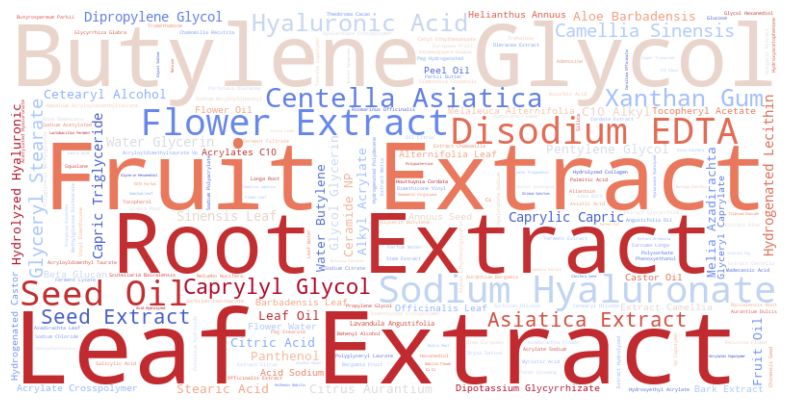

In [34]:
# 한국 스킨케어 브랜드 성분
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(k_skin_brand['ingridients'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Review")
plt.show()

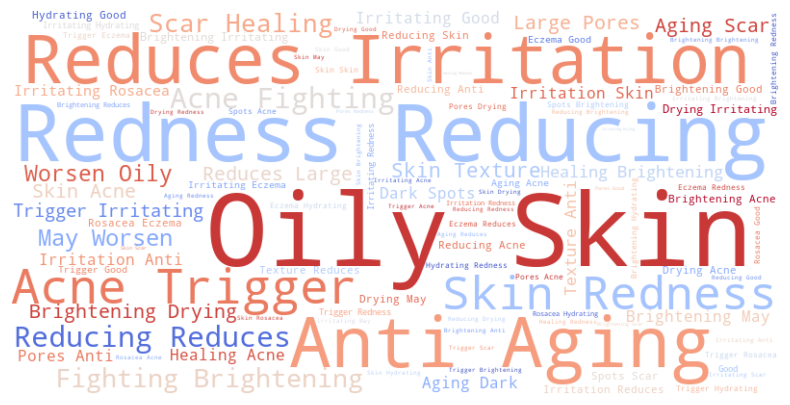

In [35]:
# 한국 스킨케어 브랜드 - 사용후
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(k_skin_brand['afterUse'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Review")
plt.show()

> 사용 후 반응
- 피부 타입 개인 차에 따른 반응들이 여기도 많음. 더 기름이 심해졌다, 건조하다 등
- 간지러움, 붉어짐 등 -> 개인적인 생각이지만 너무 특이한 성분? 약초나 시카 성분 등 자연성분을 강조한다고 너무 특이한 게 들어가면 개인 차를 많이 타는 것 같음

# PART 3: Data Analysis

#### Sentiment Analysis

In [36]:
k_skin_brand.dropna(subset=['ingridients'], inplace=True)
k_skin_brand['splitted_ingridients'] = k_skin_brand['ingridients'].apply(lambda x: str(x).split(',') if pd.notna(x) else [])

print(k_skin_brand['splitted_ingridients'].head())

k_skin_brand.dropna(subset=['afterUse'], inplace=True)
k_skin_brand['splitted_afterUse'] = k_skin_brand['afterUse'].apply(lambda x: str(x).split(',') if pd.notna(x) else [])

print(k_skin_brand['splitted_afterUse'].head())

0    [Water, Cocamidopropyl Betaine, Sodium Lauroyl...
1    [Snail Secretion Filtrate, Betaine, Caprylic/C...
2    [Water, Oryza Sativa Extract 30%, Dibutyl Adip...
3    [Water, Octocrylene, Citrullus Lanatus Fruit E...
4    [Water, Cyclopentasiloxane, Ethylhexyl Methoxy...
Name: splitted_ingridients, dtype: object
0    [Good For Oily Skin, Reduces Irritation, Reduc...
1    [Redness Reducing, Reduces Irritation, May Wor...
2    [Good For Oily Skin, Redness Reducing, Acne Fi...
3    [Drying, May Worsen Oily Skin, Acne Trigger, I...
4    [Good For Oily Skin, Redness Reducing, Brighte...
Name: splitted_afterUse, dtype: object


In [37]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# # Ensure columns are lists of strings
# column1_texts = [' '.join(ingredients) for ingredients in k_skin_brand.splitted_ingridients]
# column2_texts = [' '.join(after_use) for after_use in k_skin_brand.splitted_afterUse]

# # Apply TfidfVectorizer
# vectorizer = TfidfVectorizer()
# column1_vectors = vectorizer.fit_transform(column1_texts)
# column2_vectors = vectorizer.transform(column2_texts)

# import numpy as np
# from scipy.stats import pearsonr

# correlations = []
# for i in range(column1_vectors.shape[1]):
#     try:
#         # Calculate Pearson correlation for each feature
#         corr, _ = pearsonr(column1_vectors[:, i].toarray().flatten(), 
#                            column2_vectors[:, i].toarray().flatten())
#         correlations.append(corr)
#     except Exception as e:
#         # Handle cases where Pearson correlation fails
#         correlations.append(np.nan)

# # Visualization
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(12, 8))
# sns.heatmap(np.array(correlations).reshape(-1, 1), 
#             cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
# plt.title('Element-wise Correlation between Two Text Columns')
# plt.show()

In [38]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Create an instance of SentimentIntensityAnalyzer, which is part of the VADER sentiment analysis tool.
analyzer = SentimentIntensityAnalyzer()

# Function to apply VADER sentiment analysis to each review.
# The function takes in a 'review' (text) and returns the polarity scores, which include
# 'compound', 'positive', 'negative', and 'neutral' sentiment values.
def get_sentiment(review):
    return analyzer.polarity_scores(review)

# Apply the 'get_sentiment' function to each entry in the 'Cleaned_Review' column.
# Store the resulting sentiment scores (dictionary) in a new column 'vader_scores'.
amazon_df['cleaned_review'] = amazon_df['cleaned_review'].astype(str)
amazon_df['vader_scores'] = amazon_df['cleaned_review'].apply(get_sentiment)

k_skin_brand['afterUse'] = k_skin_brand['afterUse'].astype(str)
k_skin_brand['vader_scores'] = k_skin_brand['afterUse'].apply(get_sentiment)

# Extract the 'compound' score from the 'vader_scores' dictionary for each review.
# The 'compound' score is a normalized score ranging from -1 (most negative) to +1 (most positive),
# summarizing the overall sentiment of the text.
amazon_df['compound'] = amazon_df['vader_scores'].apply(lambda score_dict: score_dict['compound'])
k_skin_brand['compound'] = k_skin_brand['vader_scores'].apply(lambda score_dict: score_dict['compound'])

# Function to classify the sentiment based on the 'compound' score.
# Scores >= 0.05 are classified as 'Positive', <= -0.05 as 'Negative', and anything in between as 'Neutral'.
def classify_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply the 'classify_sentiment' function to the 'compound' score to get the overall sentiment
# classification (Positive, Negative, or Neutral) for each review.
amazon_df['sentiment'] = amazon_df['compound'].apply(classify_sentiment)
k_skin_brand['sentiment'] = k_skin_brand['compound'].apply(classify_sentiment)

# Display the first few rows of the DataFrame, showing the cleaned review text,
# the 'compound' sentiment score, and the classified 'sentiment'.
print(amazon_df[['cleaned_review', 'compound', 'sentiment']].head(2))

                                      cleaned_review  compound sentiment
0  this lotion is one of my favorites super moist...    0.5187  Positive
1  if you wash your hands frequently due to work ...    0.5377  Positive


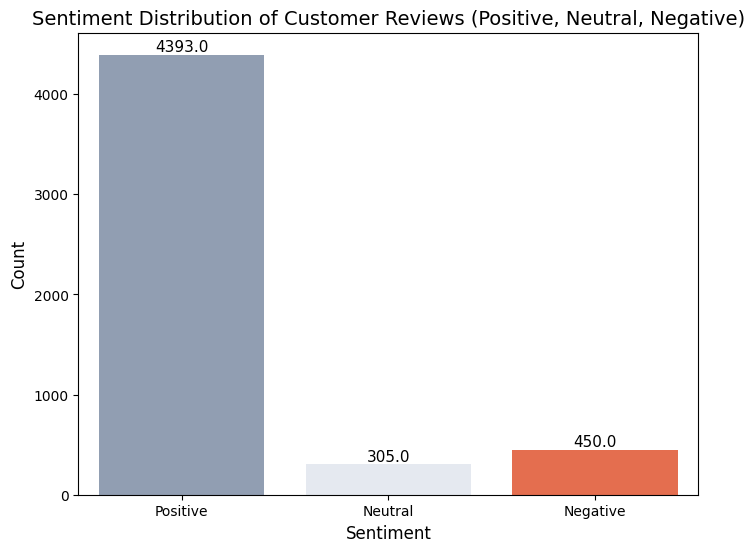

In [40]:
# 아마존
# Assuming df is already loaded and contains the 'sentiment' column
plt.figure(figsize=(8, 6))

# Count plot with a specific color palette
sns.countplot(data=amazon_df, x='sentiment', palette=skin_palette)

# Add title and axis labels with adjusted font sizes
plt.title('Sentiment Distribution of Customer Reviews (Positive, Neutral, Negative)', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Adding data labels on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), 
                       ha='center', va='bottom', fontsize=11)

# Display the plot
plt.show()

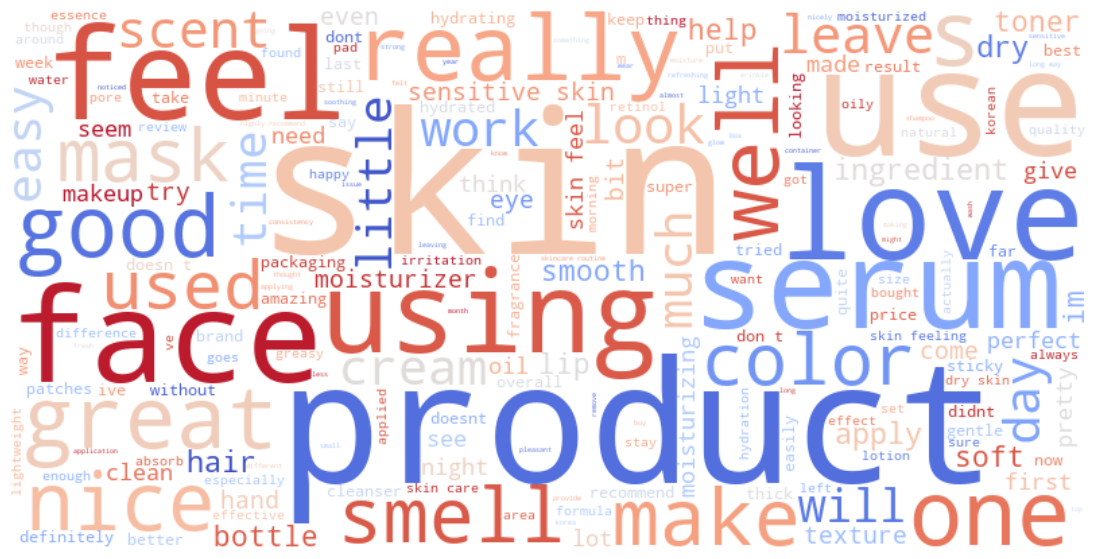

In [41]:
# 긍정적 리뷰 내용 - 워드 클라우드
query_cond = 'sentiment == "Positive"'
pos_df = amazon_df.query(query_cond)
pos_df.reset_index(drop=True, inplace=True)

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(pos_df['cleaned_review'].dropna()))
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Title")
plt.show()

> 긍정 리뷰
- 수분 : hydration, hydrated, moisturing, moisture 
- 카테고리 : skin-care, make-up (카테고리인지, 메이크업할 때 잘 먹는다는 건지는 원본을 봐야알듯)
            skin, skin-care, skincare routine 등이 많음
- 아이템 : oil, serum, cleanser, toner, cream
- 시간 : morning, night ..
    
    - 스킨케어 루틴 중에 일상적으로 이용, 수분감 등 기능성에 긍정적 반응이 주로 (현재 샘플 데이터 기준)
    현재, K-beauty 의 경우 Skin care 쪽으로 미국에서 반응이 좋은데 이 부분과 일치하는 리뷰 내용임.

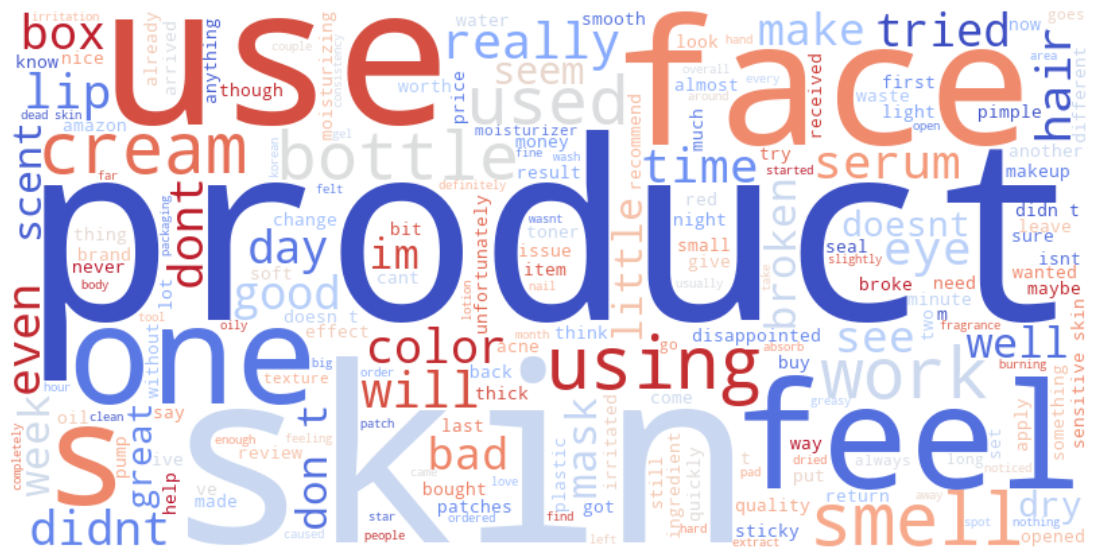

In [42]:
# 부정정적 리뷰 내용 - 워드 클라우드
query_cond = 'sentiment == "Negative"'
neg_df = amazon_df.query(query_cond)
neg_df.reset_index(drop=True, inplace=True)

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(neg_df['cleaned_review'].dropna()))
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Title")
plt.show()

> 부정 리뷰
- dry <-> sticky, expected (기대치에 떨어진듯), money (돈이 아깝다는 건지, 비싸다는 건지 리뷰 원본 봐야됨), waste, damaged (제품 패키지가 손상? 본인의 피부가 손상?), horrible..

    - 건조하다 <-> 끈적거린다 : 이거는 고객 피부 타입별로 맞춤형 필요해보임
        waste, damaged, horrible 등 최악의 평가를 받은 리뷰는 내용 확인해볼 필요 있어보임.

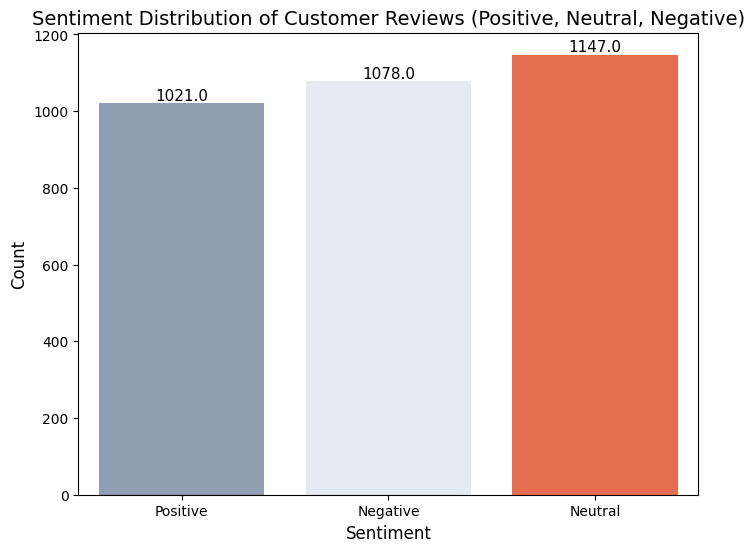

In [43]:
# 스킨쏘트
# Assuming df is already loaded and contains the 'sentiment' column
plt.figure(figsize=(8, 6))

# Count plot with a specific color palette
sns.countplot(data=k_skin_brand, x='sentiment', palette=skin_palette)

# Add title and axis labels with adjusted font sizes
plt.title('Sentiment Distribution of Customer Reviews (Positive, Neutral, Negative)', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Adding data labels on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), 
                       ha='center', va='bottom', fontsize=11)

# Display the plot
plt.show()

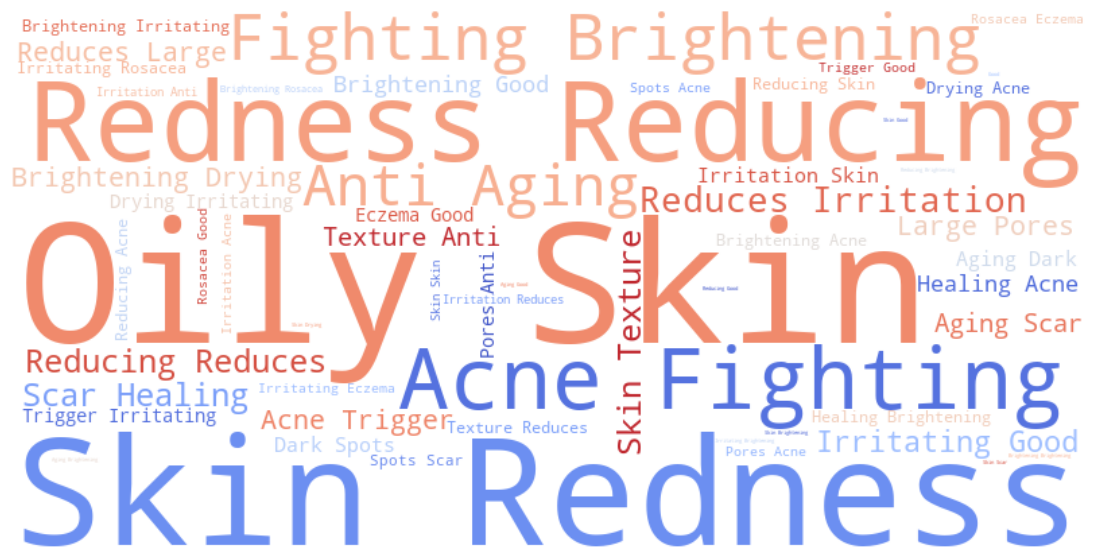

In [44]:
# 긍정적 리뷰 내용 - 워드 클라우드
query_cond = 'sentiment == "Positive"'
pos_df = k_skin_brand.query(query_cond)
pos_df.reset_index(drop=True, inplace=True)

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(pos_df['afterUse'].dropna()))
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Title")
plt.show()

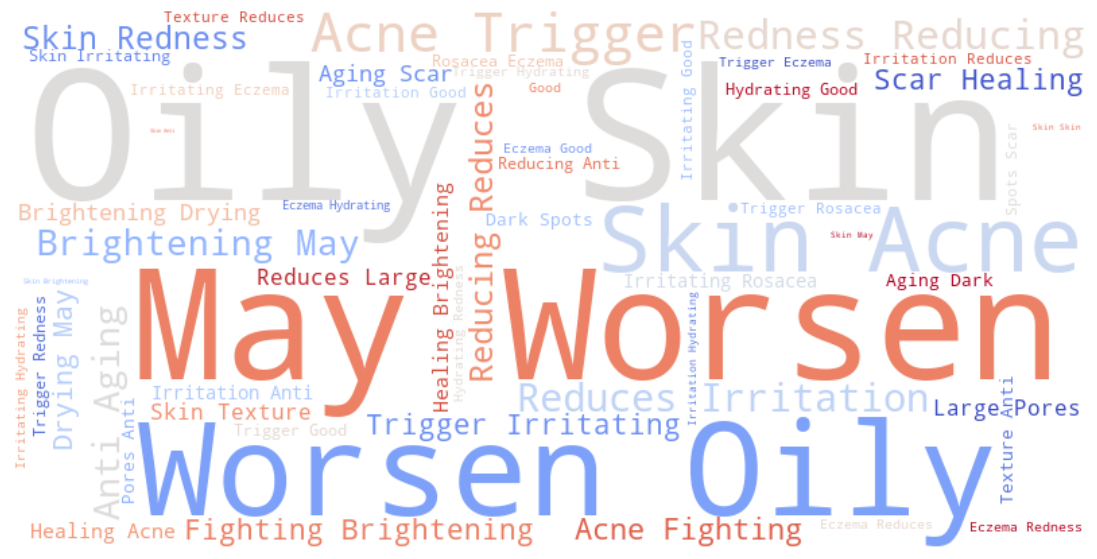

In [45]:
# 부정적 리뷰 내용 - 워드 클라우드
query_cond = 'sentiment == "Negative"'
pos_df = k_skin_brand.query(query_cond)
pos_df.reset_index(drop=True, inplace=True)

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(pos_df['afterUse'].dropna()))
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Title")
plt.show()

#### Topic Modeling

https://towardsdatascience.com/end-to-end-topic-modeling-in-python-latent-dirichlet-allocation-lda-35ce4ed6b3e0

> 토픽 모델링을 저희가 가진 컬럼 별로 더 상세하게 진행해해보면, 의미있는 주제 별로 정리해볼 수 있을 것 같습니다.
- 현재 아래 코드 적용된 예시) 아마존 데이터의 리뷰 데이터
- (추가 아이디어) 
 - skinsort 에 afterUse 컬럼 (사용효과) : 수분있는, 보습잘되는, 자극없는, 트러블안생기는 .. 등
 - 아마존이나 스킨쏘트 데이터에 성분 컬럼: 성분들 토픽 별로 묶음
 - 피부 타입에 대한 게 있으면 또 좋을 것 같음: ?

In [ ]:
# Prepare data for LDA Analysis
import gensim
from gensim.utils import simple_preprocess

stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use'])

def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))
        
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) 
             if word not in stop_words] for doc in texts]
    
data = amazon_df.stpw_processed_review.tolist()
data_words = list(sent_to_words(data))
# remove stop words
data_words = remove_stopwords(data_words)
print(data_words[:1][0][:30])

['lotion', 'one', 'favorites', 'super', 'moisturizing', 'greasy']


In [44]:
import gensim.corpora as corpora
# Create Dictionary
id2word = corpora.Dictionary(data_words)
# Create Corpus
texts = data_words
# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]
# View
print(corpus[:1][0][:30])

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1)]


In [45]:
# LDA model training
from pprint import pprint
# number of topics
num_topics = 10
# Build LDA model
lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                       id2word=id2word,
                                       num_topics=num_topics)
# Print the Keyword in the 10 topics
pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

[(0,
  '0.017*"skin" + 0.014*"face" + 0.011*"product" + 0.009*"like" + 0.008*"well" '
  '+ 0.008*"oil" + 0.007*"little" + 0.007*"color" + 0.007*"makeup" + '
  '0.006*"nice"'),
 (1,
  '0.023*"skin" + 0.018*"face" + 0.010*"love" + 0.008*"serum" + 0.008*"good" + '
  '0.008*"well" + 0.008*"really" + 0.006*"cream" + 0.006*"bottle" + '
  '0.006*"product"'),
 (2,
  '0.027*"skin" + 0.015*"product" + 0.015*"love" + 0.010*"like" + '
  '0.009*"using" + 0.008*"used" + 0.007*"cream" + 0.007*"good" + '
  '0.007*"really" + 0.006*"one"'),
 (3,
  '0.032*"skin" + 0.022*"like" + 0.010*"great" + 0.010*"product" + '
  '0.008*"serum" + 0.008*"feels" + 0.007*"really" + 0.007*"one" + '
  '0.007*"would" + 0.006*"cream"'),
 (4,
  '0.029*"skin" + 0.016*"like" + 0.013*"product" + 0.011*"face" + '
  '0.010*"really" + 0.009*"good" + 0.008*"feel" + 0.007*"mask" + 0.007*"nice" '
  '+ 0.007*"love"'),
 (5,
  '0.029*"skin" + 0.011*"product" + 0.009*"patches" + 0.008*"great" + '
  '0.008*"well" + 0.008*"really" + 0.008*"

In [48]:
import pyLDAvis.gensim
import pickle 
import pyLDAvis
# Visualize the topics
pyLDAvis.enable_notebook()
LDAvis_data_filepath = os.path.join('./results/ldavis_prepared_'+str(num_topics))
# # this is a bit time consuming - make the if statement True
# # if you want to execute visualization prep yourself
if 1 == 1:
    LDAvis_prepared = pyLDAvis.gensim.prepare(lda_model, corpus, id2word)
    with open(LDAvis_data_filepath, 'wb') as f:
        pickle.dump(LDAvis_prepared, f)
# load the pre-prepared pyLDAvis data from disk
with open(LDAvis_data_filepath, 'rb') as f:
    LDAvis_prepared = pickle.load(f)
pyLDAvis.save_html(LDAvis_prepared, './results/ldavis_prepared_'+ str(num_topics) +'.html')
LDAvis_prepared

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.000474  0.002770       1        1  20.175843
4      0.012117  0.006279       2        1  18.775674
7      0.011149  0.021174       3        1  11.397466
6      0.008724 -0.010382       4        1  11.113664
8      0.000657 -0.006946       5        1  10.389476
9      0.010155 -0.008851       6        1   7.131272
5     -0.013411 -0.006131       7        1   6.168645
0      0.004100  0.043651       8        1   5.709523
2     -0.057691 -0.007752       9        1   5.275019
1      0.024673 -0.033811      10        1   3.863418, topic_info=                 Term         Freq        Total Category  logprob  loglift
154              skin  4338.000000  4338.000000  Default  30.0000  30.0000
98               face  1394.000000  1394.000000  Default  29.0000  29.0000
79            product  1784.000000  1784.000000  Default  28.0000  28.0000
104              love   965.000000   965.000000  Default  27.0000  27.0000
666              hair   532.000000   532.000000  Default  26.0000  26.0000
1200            serum   928.000000   928.000000  Default  25.0000  25.0000
54               well   964.000000   964.000000  Default  24.0000  24.0000
508             using   976.000000   976.000000  Default  23.0000  23.0000
61              great  1018.000000  1018.000000  Default  22.0000  22.0000
1710          patches   353.000000   353.000000  Default  21.0000  21.0000
193              used   663.000000   663.000000  Default  20.0000  20.0000
586             color   518.000000   518.000000  Default  19.0000  19.0000
1832              oil   420.000000   420.000000  Default  18.0000  18.0000
78               good  1030.000000  1030.000000  Default  17.0000  17.0000
13              cream   711.000000   711.000000  Default  16.0000  16.0000
41             really  1083.000000  1083.000000  Default  15.0000  15.0000
27             little   610.000000   610.000000  Default  14.0000  14.0000
1301           makeup   355.000000   355.000000  Default  13.0000  13.0000
36               much   530.000000   530.000000  Default  12.0000  12.0000
4                 one   774.000000   774.000000  Default  11.0000  11.0000
1080           bottle   508.000000   508.000000  Default  10.0000  10.0000
52               wash   240.000000   240.000000  Default   9.0000   9.0000
111          products   588.000000   588.000000  Default   8.0000   8.0000
325              like  1891.000000  1891.000000  Default   7.0000   7.0000
249           without   429.000000   429.000000  Default   6.0000   6.0000
96                dry   647.000000   647.000000  Default   5.0000   5.0000
133                im   441.000000   441.000000  Default   4.0000   4.0000
158               bit   455.000000   455.000000  Default   3.0000   3.0000
393              time   583.000000   583.000000  Default   2.0000   2.0000
181              nice   777.000000   777.000000  Default   1.0000   1.0000
5514          grandma     3.027376     3.840630   Topic1  -9.2268   1.3627
8769        affection     2.050703     2.863927   Topic1  -9.6163   1.2667
6274           walked     2.050609     2.863833   Topic1  -9.6164   1.2667
7043         approval     2.050345     2.863592   Topic1  -9.6165   1.2666
6826        festivals     2.050219     2.863449   Topic1  -9.6166   1.2666
6969          student     2.049817     2.863075   Topic1  -9.6167   1.2665
5726       creamserum     2.036109     2.862067   Topic1  -9.6235   1.2602
3926        warehouse     2.021268     2.865247   Topic1  -9.6308   1.2518
5306          minimum     2.682728     3.827235   Topic1  -9.3477   1.2454
4917             lash     1.988030     2.863363   Topic1  -9.6474   1.2358
7177          outline     1.985969     2.863550   Topic1  -9.6484   1.2347
1696            thumb     1.973190     2.867825   Topic1  -9.6548   1.2268
1292           sudden     1.930936     2.839349   Topic1  -9.6765   1.2151
166      

#### Kbeauty Brand Clustering

> 브랜드 클러스터링
 - feature 1. Type 제품 유형
   - pca : 4 요인 (엘보우 5, feature를 모두 개별로 돌려봄 해석이 가능해지는 클러스터링 결과물이 되도록)
   - 설명력 : 0.8038
 - feature 2. Ingredient 성분
   - pca : 4 요인 (엘보우 6)
   - 설명력 : 0.55
 - feature 3. afterUse 사용효과
   - pca : 4 요인 (엘보우 7)
   - 설명력 : 0.85

In [76]:
# 브랜드 클러스터링용 데이터프레임 별도 생성
cond = '''brand=="I'm from" or brand=="Beauty of Joseon" or brand=="PURITO"'''
clustering_df = amazon_df.query(cond)

skinsort_clustering = skinsort_copy.query(cond)
skinsort_clustering.brand.value_counts()

km_df = pd.merge(clustering_df, skinsort_clustering, how='inner', on='brand')
km_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9374 entries, 0 to 9373
Data columns (total 61 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   ASIN                             9374 non-null   object        
 1   title                            9374 non-null   object        
 2   order                            9374 non-null   int64         
 3   Amazon_Category                  9374 non-null   object        
 4   brand                            9374 non-null   object        
 5   price                            9374 non-null   float64       
 6   global_rating_count              9374 non-null   Int64         
 7   description                      9374 non-null   object        
 8   Special_Feature                  5652 non-null   object        
 9   total_star_mean                  9374 non-null   float64       
 10  Manufacturer                     9374 non-null   object     

In [78]:
km_df.cleaned_afterUse

0                                      dryingacne trigger
1               antiagingmay worsen oily skinacne trigger
2                        may worsen oily skinacne trigger
3                  brighteningmay worsen oily skinrosacea
4                  reduces irritationmay worsen oily skin
5                                             brightening
6                                                  drying
7                        scar healingmay worsen oily skin
8       good for oily skinreduces large poresacne figh...
9                                      reduces irritation
10      reduces irritationbrighteningmay worsen oily s...
11      redness reducingscar healingbrighteningdryingm...
12      good for oily skinskin textureantiagingscar he...
13                    reduces irritationbrighteningeczema
14      good for oily skinredness reducingskin texture...
15      good for oily skinskin textureantiagingscar he...
16                                     reduces irritation
17            

In [77]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 클러스터링 할 컬럼 지정
# feature_names=['type','ingridients', 'cleaned_ingridients','afterUse','cleaned_review','cleaned_afterUse']
feature_1 = ['type']
feature_2 = ['cleaned_ingridients']
feature_3 = ['cleaned_afterUse']
km_base_df = pd.DataFrame(km_df, columns=feature_3)
df = km_base_df

# TF-IDF 벡터화
tfidf_vectorizer = TfidfVectorizer(
    max_features=10,  
    stop_words="english",  
    ngram_range=(1, 2)  
)

# 컬럼별 TF-IDF 변환
tfidf_results = {}
# for column in feature_names:
for column in feature_3:
    # NaN 제거 후 TF-IDF 적용
    tfidf_matrix = tfidf_vectorizer.fit_transform(df[column].dropna())
    
    # TF-IDF 결과를 데이터프레임으로 저장
    tfidf_results[column] = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=[f"{column}_{feature}" for feature in tfidf_vectorizer.get_feature_names_out()]
    )

final_tfidf_df = pd.concat(tfidf_results.values(), axis=1)

# 표준화
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
imputed_scale_df = imputer.fit_transform(final_tfidf_df)

# 표준화 방식: standard scaler (평균0, 분산1)
std_scale_df = StandardScaler().fit_transform(imputed_scale_df)

# 주성분 개수를 판단하기 위한 pca임의 시행 
pca = PCA(n_components=4)
pca.fit(std_scale_df)
# 설정한 주성분의 갯수로 전체 데이터 분산을 얼만큼 설명 가능한지 
pca.explained_variance_ratio_.sum()

0.8560766120839391

In [79]:
# pca 시행
pca_df = pca.fit_transform(std_scale_df)
pca_df = pd.DataFrame(data = pca_df, columns = ['PC1','PC2','PC3','PC4'])  

pca_df.head()

,PC1,PC2,PC3,PC4
0,-1.604985,-2.061298,-1.769406,1.934448
1,-0.970580,-2.715453,1.589754,1.261013
2,-0.970580,-2.715453,1.589754,1.261013
3,-0.543457,-2.408449,2.888801,-0.494265
4,-0.543457,-2.408449,2.888801,-0.494265


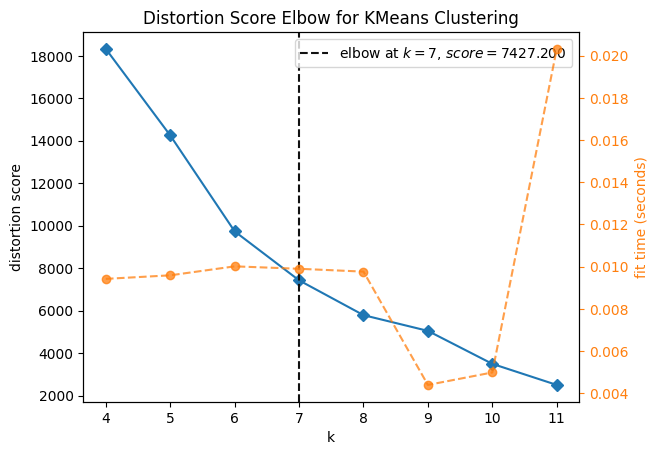

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [80]:
# 초기 k 값 참고를 위한 scree plot 을 그리고, 군집이 나뉘는 시간까지 고려한 k 값 확인 
model = KMeans()

# k 값의 범위를 조정해 줄 수 있습니다. 
visualizer = KElbowVisualizer(model, k=(4,12))

# 데이터 적용 
visualizer.fit(pca_df) 
visualizer.show()

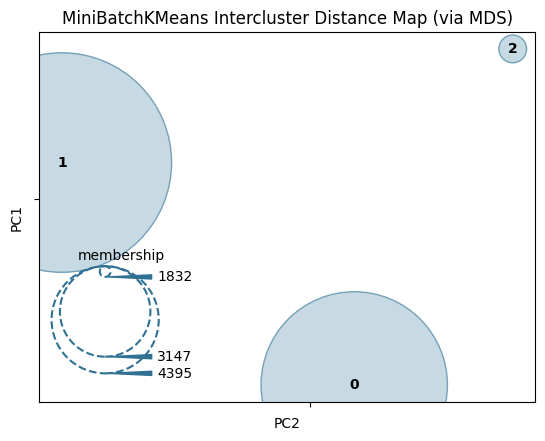

InterclusterDistance(ax=<Axes: title={'center': 'MiniBatchKMeans Intercluster Distance Map (via MDS)'}, xlabel='PC2', ylabel='PC1'>,
                     estimator=MiniBatchKMeans(n_clusters=3, random_state=42))

In [81]:
# 초기 k 값 참고를 위한 distance map 시각화
#그룹의 갯수를 지정해 줄 수 있습니다. 저는 5로 적어두었습니다. 
intercluster_distance(MiniBatchKMeans(3, random_state=42), pca_df)

In [82]:
#  KMEANS
# 군집개수(n_cluster)는 5,초기 중심 설정방식 랜덤,  
kmeans = KMeans(n_clusters=3, random_state=42, init='random')

# pca df 를 이용한 kmeans 알고리즘 적용
kmeans.fit(pca_df)

# 클러스터 번호 가져오기 
labels = kmeans.labels_

# 클러스터 번호가 할당된 데이터셋 생성
kmeans_df = pd.concat([pca_df, pd.DataFrame({'Cluster':labels})],axis = 1)

# 클러스터 번호가 할당된 데이터셋 생성
kmeans_df.groupby(['Cluster'])['PC1'].count().reset_index()

,Cluster,PC1
0,0,4395
1,1,1832
2,2,3147


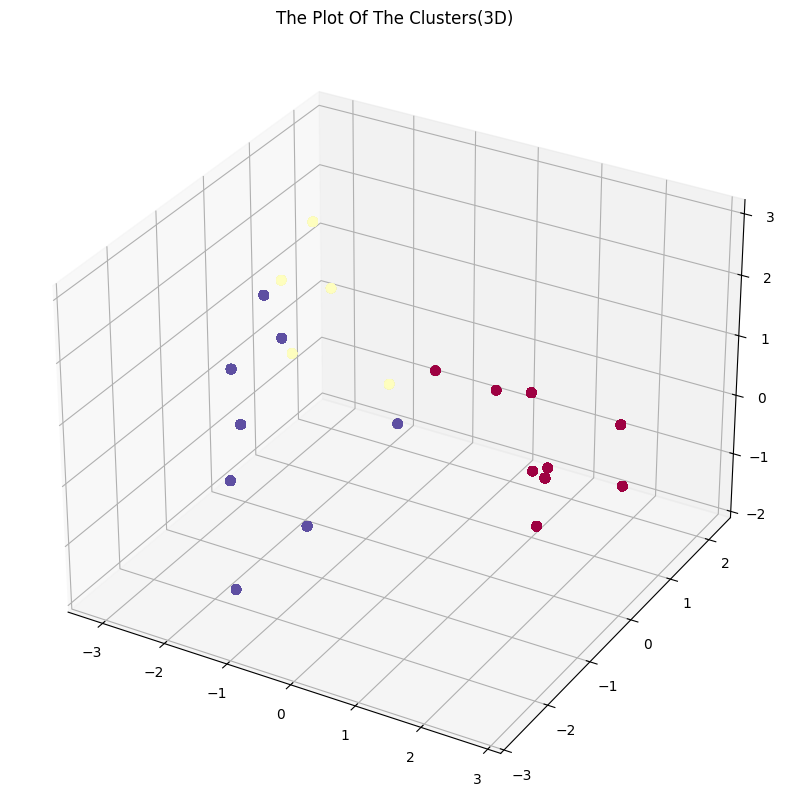

In [83]:
# 3차원으로 시각화 
x =kmeans_df["PC1"]
y =kmeans_df["PC2"]
z =kmeans_df["PC3"]

fig = plt.figure(figsize=(12,10))
ax = plt.subplot(111, projection='3d')
ax.scatter(x, y, z, s=40, c=kmeans_df["Cluster"], marker='o', alpha = 0.5, cmap = 'Spectral')
ax.set_title("The Plot Of The Clusters(3D)")

plt.show()

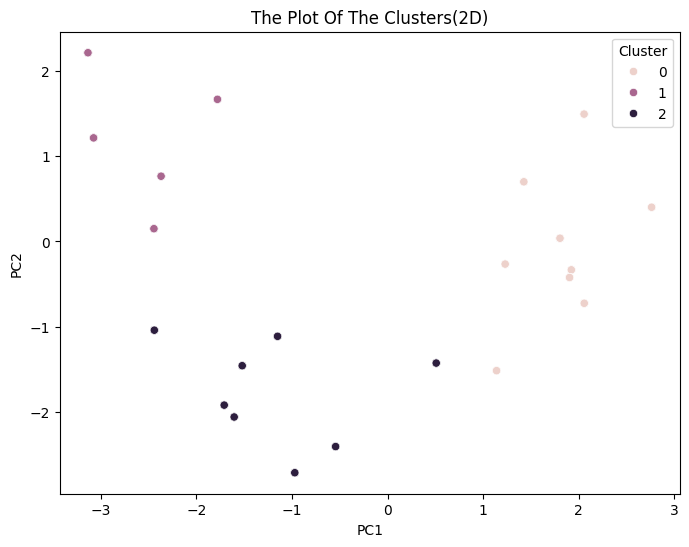

In [84]:
# 2차원으로 시각화

plt.figure(figsize=(8,6))

sns.scatterplot(data = kmeans_df, x = 'PC1', y='PC2', hue='Cluster')
plt.title('The Plot Of The Clusters(2D)')
plt.show()

# PART 4: Ingredient based product attribute - Transformer

https://assets.amazon.science/c9/b1/d86e742047a9a75c9bacb0f95605/beauty-beyond-words-explainable-beauty-product-recommendations-using-ingredient-based-product-attributes.pdf

### 1. 샘플 데이터

In [ ]:
import pandas as pd

# 가상의 데이터프레임 생성
data = {
    'product_id': [1, 2, 3],
    'ingredients': ['water, glycerin, fragrance', 'glycerin, alcohol', 'water, alcohol'],
    'attributes': ['hydrating', 'drying', 'hydrating']
}

df = pd.DataFrame(data)
print(df)

   product_id                 ingredients attributes
0           1  water, glycerin, fragrance  hydrating
1           2           glycerin, alcohol     drying
2           3              water, alcohol  hydrating


### 2. 텍스트 처리 (성분 전처리)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# 성분을 벡터화
vectorizer = CountVectorizer()
ingredient_vectors = vectorizer.fit_transform(df['ingredients'])

# 성분 벡터 출력
print("Feature Names:", vectorizer.get_feature_names_out())
print("Ingredient Vectors:\n", ingredient_vectors.toarray())

Feature Names: ['alcohol' 'fragrance' 'glycerin' 'water']
Ingredient Vectors:
 [[0 1 1 1]
 [1 0 1 0]
 [1 0 0 1]]


### 3. 속성 인코딩

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 속성 레이블 인코딩
label_encoder = LabelEncoder()
attribute_labels = label_encoder.fit_transform(df['attributes'])

# 변환된 속성 출력
print("Encoded Attributes:", attribute_labels)

Encoded Attributes: [1 0 1]


### 4. 모델 정의

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 간단한 에너지 기반 모델 정의
class EnergyBasedModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(EnergyBasedModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# 모델 초기화
input_dim = ingredient_vectors.shape[1]
output_dim = len(set(attribute_labels))
model = EnergyBasedModel(input_dim, output_dim)
print(model)

EnergyBasedModel(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)


### 5. 모델 학습

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 간단한 에너지 기반 모델 정의
class EnergyBasedModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(EnergyBasedModel, self).__init__()
        
        # 첫 번째 레이어: 입력 차원에서 128개의 중간 차원으로 변환
        # 논문에서는 입력된 성분 벡터와 속성 벡터 사이의 관계를 학습한다고 했음.
        # 이를 위해 충분히 복잡한 표현을 학습할 수 있도록 중간 차원을 설정.
        self.fc1 = nn.Linear(input_dim, 128)  # 입력 -> 중간 표현

        # 두 번째 레이어: 중간 차원에서 출력 차원(속성 수)으로 변환
        # 최종적으로 모델은 성분 벡터가 각 속성과 얼마나 연관이 있는지 에너지 값을 반환해야 함.
        self.fc2 = nn.Linear(128, output_dim)  # 중간 표현 -> 출력

    def forward(self, x):
        # 첫 번째 레이어를 통과한 결과에 ReLU 활성화 함수 적용
        # 비선형성을 추가하여 복잡한 관계를 모델링 가능하게 함.
        x = torch.relu(self.fc1(x))
        
        # 최종 출력 생성: 성분 벡터와 속성 간의 관계를 나타내는 값 반환
        return self.fc2(x)

# 모델 초기화
# input_dim: 성분 벡터의 차원 수 (벡터화된 성분의 고유 단어 개수)
# output_dim: 속성 벡터의 차원 수 (속성의 고유 클래스 수)
input_dim = ingredient_vectors.shape[1]
output_dim = len(set(attribute_labels))

# 에너지 기반 모델 인스턴스 생성
model = EnergyBasedModel(input_dim, output_dim)

# 모델 구조 출력
print(model)

# 학습 데이터 준비
X = torch.tensor(ingredient_vectors.toarray(), dtype=torch.float32)
y = torch.tensor(attribute_labels, dtype=torch.long)

# 손실 함수 및 옵티마이저 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 학습 루프
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# 모델 평가
_, predicted = torch.max(model(X), 1)
accuracy = (predicted == y).sum().item() / len(y)
print(f'Accuracy: {accuracy * 100:.2f}%')

EnergyBasedModel(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)
Epoch [10/100], Loss: 0.1333
Epoch [20/100], Loss: 0.0099
Epoch [30/100], Loss: 0.0014
Epoch [40/100], Loss: 0.0006
Epoch [50/100], Loss: 0.0004
Epoch [60/100], Loss: 0.0003
Epoch [70/100], Loss: 0.0003
Epoch [80/100], Loss: 0.0002
Epoch [90/100], Loss: 0.0002
Epoch [100/100], Loss: 0.0002
Accuracy: 100.00%


### 6. 모델 평가

In [ ]:
# 예측 수행
_, predicted = torch.max(model(X), 1)

# 정확도 계산
accuracy = (predicted == y).sum().item() / len(y)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 100.00%
